# JCAS Monte-Carlo: band comparison plot book

Compares **3.5 GHz / 10 GHz / 28 GHz** over the same 15 Monte-Carlo scenes
(5 deployment radii x 3 densities) from `3.5ghz.csv`, `10ghz.csv`, `28ghz.csv`.

Two granularities live in the same CSV:

* **scene-level KPIs** (repeated on every drone row of a scene): `prob_detection`,
  `false_alarms_per_frame`, `false_alarm_fraction`, `rmse_position_error_m`
* **per-drone KPIs**: `snr_db`, `sensing_snr_db`, `ber`, `throughput_mbps`, `detected`,
  and — only for detected drones — `position_error_m`, `range_error_m`, `azimuth_error_deg`

Two different SNRs live here and are labelled as such on every axis:

* **comms SNR** (`snr_db`) — one-way **BS→drone**, post-equalisation EVM SINR of the
  downlink. Falls as 1/R².
* **sensing SNR** (`sensing_snr_db`) — two-way **BS→drone→BS**, the monostatic radar
  return at the drone's own range/Doppler/bearing cell over the CFAR noise floor.
  Falls as 1/R⁴. Written only by sweeps run after `per_target_sensing_snr()` was added;
  older CSVs lack the column and those plots fall back to comms-only.

Density is stored in the CSVs as drones/m² but **plotted as drones/km²** (500 / 1000 /
1500) throughout.

**Four sweep axes, two of them held.** The CSV now carries `band`, `comb_spacing` and
`pfa` alongside the scene axes (`range_m`, `density_per_km2`). Sections 0-5 compare
BANDS, so they run on one slice of the other two — the loader picks the most-populated
value and `save()` stamps it in the bottom-right of every figure it draws, e.g.
*held at comb M=off, pfa=1e-04*. **Section 6** is the complement: it plots the comb and
detector axes themselves off the unsliced frame, and its figures carry no stamp.

Every figure is written to `plots/` as a PNG so you can pull the ones you want.

Data caveats worth knowing before you quote a number:
* 14 rows have `snr_db = -inf` (zero received power) — treated as *link outage* and
  excluded from SNR statistics, counted separately.
* `rmse_position_error_m` is NaN for scenes where nothing was detected (Pd = 0), and
  per-drone error columns exist for only 58 of 561 rows.
* 3.5 GHz and 10 GHz share identical drone geometry; the 28 GHz run's positions differ
  by <0.3 m. Paired band comparisons join on `(scene_id, drone_id)`, which stays valid.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

PLOTS = Path('plots'); PLOTS.mkdir(exist_ok=True)

# ---- palette (validated categorical slots 1-3, light surface) -------------------
SURFACE   = '#fcfcfb'
INK       = '#0b0b0b'
INK_2     = '#52514e'
INK_MUTED = '#8b8a85'
GRID      = '#e4e3df'

BANDS = [3.5, 10.0, 28.0]
COLOR = {3.5: '#2a78d6', 10.0: '#eb6834', 28.0: '#1baf7a'}   # blue / orange / aqua
NAME  = {3.5: '3.5 GHz', 10.0: '10 GHz', 28.0: '28 GHz'}
MARK  = {3.5: 'o', 10.0: 's', 28.0: '^'}                     # secondary encoding

BLUES = ['#cde2fb', '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec', '#5598e7',
         '#3987e5', '#2a78d6', '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b']
SEQ = LinearSegmentedColormap.from_list('seq_blue', BLUES)
SEQ.set_bad('#f0efec')
DIV = LinearSegmentedColormap.from_list('div_br', ['#0d366b', '#3987e5', '#cde2fb',
                                                   '#f0efec', '#f6b8b8', '#e34948', '#8f1f1f'])
DIV.set_bad('#f0efec')

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK_2, 'axes.titlecolor': INK,
    'axes.titlesize': 11, 'axes.titleweight': 'semibold', 'axes.titlelocation': 'left',
    'axes.titlepad': 10, 'axes.labelsize': 9.5, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.color': GRID,
    'grid.linewidth': 0.8, 'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'xtick.labelcolor': INK_2, 'ytick.labelcolor': INK_2, 'xtick.labelsize': 9,
    'ytick.labelsize': 9, 'legend.frameon': False, 'legend.fontsize': 9,
    'legend.labelcolor': INK_2, 'lines.linewidth': 2.0, 'lines.markersize': 6,
    'font.size': 10, 'figure.dpi': 110,
})

# Sections 0-5 draw from one slice of the comb/pfa axes, which save() stamps on every
# figure. Section 6 spans those axes and passes note='' to suppress it.
HELD_NOTE = ''

def save(fig, name, note=None):
    txt = HELD_NOTE if note is None else note
    if txt:
        fig.text(0.995, 0.0, txt, ha='right', va='top', fontsize=8, color=INK_MUTED,
                 style='italic')
    fig.savefig(PLOTS / f'{name}.png', dpi=170, bbox_inches='tight', facecolor=SURFACE)
    plt.show()

def binstat(x, y, bins, stat='mean'):
    '''Aggregate y within bins of x. Returns (centers, values, counts).'''
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    idx = np.digitize(x, bins) - 1
    cen, val, cnt = [], [], []
    for i in range(len(bins) - 1):
        m = idx == i
        cen.append(0.5 * (bins[i] + bins[i + 1]))
        cnt.append(int(m.sum()))
        val.append(getattr(np, 'nan' + ('mean' if stat == 'mean' else stat))(y[m]) if m.sum() else np.nan)
    return np.array(cen), np.array(val), np.array(cnt)

def ecdf(v):
    v = np.sort(np.asarray(v, float))
    v = v[np.isfinite(v)]
    return v, np.arange(1, v.size + 1) / v.size

def heat(ax, piv, cmap=SEQ, fmt='{:.2f}', vmin=None, vmax=None, title=''):
    M = piv.to_numpy(float)
    im = ax.imshow(np.ma.masked_invalid(M), cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(piv.shape[1]), [f'{c:g}' for c in piv.columns])
    ax.set_yticks(range(piv.shape[0]), [f'{r:g}' for r in piv.index])
    ax.set_title(title)
    ax.grid(False)
    lo, hi = (np.nanmin(M), np.nanmax(M)) if np.isfinite(M).any() else (0, 1)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = M[i, j]
            if not np.isfinite(v):
                ax.text(j, i, 'n/a', ha='center', va='center', color=INK_MUTED, fontsize=8)
                continue
            frac = 0 if hi == lo else (v - lo) / (hi - lo)
            ax.text(j, i, fmt.format(v), ha='center', va='center', fontsize=8,
                    color='#ffffff' if frac > 0.62 else INK)
    return im

print('setup ok')

setup ok


In [2]:
from pathlib import Path

# one csv per sweep, with a `band` column, since band is itself a sweep axis
SINGLE_CSV = Path('monte_carlo_kpis.csv')
df = pd.read_csv(SINGLE_CSV)
print(f'loaded {SINGLE_CSV}: {len(df)} rows, bands {sorted(df.band.unique())}')
df['band'] = df['band'].astype(float)

# the bands actually present, not the catalogue in the style cell; NAME/COLOR keep
# their fixed entries so a band always gets the same colour
BANDS = sorted(df['band'].unique())
for _b in BANDS:
    NAME.setdefault(_b, f'{_b:g} GHz')
    COLOR.setdefault(_b, INK_MUTED)
    MARK.setdefault(_b, 'o')
print('bands in this file:', [NAME[b] for b in BANDS])
BASE = BANDS[0] if BANDS else None    # section 3's difference baseline
OTHERS = BANDS[1:]

# -inf SNR = no received power -> outage flag, excluded from SNR stats
df['outage'] = ~np.isfinite(df['snr_db'])
df['snr'] = df['snr_db'].where(~df['outage'])
df['link_ok'] = df['ber'] < 1e-2                      # "usable link" threshold
df['bandname'] = df['band'].map(NAME)
# `density` is an alias: the correlation matrix and scene groupby key on that name
df['density_km2'] = df['density_per_km2'].astype(float).round(3)
df['density'] = df['density_km2']
# `snr_db` is the comms link (one-way, EVM SINR); `sensing_snr_db` the sensing link
# (two-way, against the CFAR noise floor)
df['sensing_snr'] = df['sensing_snr_db'].where(np.isfinite(df['sensing_snr_db']))
df['horiz_range_m'] = np.hypot(df['x'], df['y'])
df['speed_mps'] = np.hypot(df['vx'], df['vy'])

SC_COLS = ['prob_detection', 'false_alarms_per_frame', 'false_alarm_fraction',
           'rmse_position_error_m']

# --- the waveform/detector axes -------------------------------------------------
# Sections 0-5 compare bands, so comb/pfa are held at one slice there; otherwise each
# scene appears once per detector setting and the `.first()` below keeps an arbitrary
# row. `df_all` keeps every row for section 6.
df_all = df.copy()
AXES = [a for a in ('comb_spacing', 'pfa') if a in df.columns]
HELD = {}
for _axis in AXES:
    if df[_axis].nunique() > 1:
        HELD[_axis] = df[_axis].value_counts().idxmax()      # most-populated value
        print(f'{_axis}: {sorted(df[_axis].unique())} present -> holding at {HELD[_axis]}')
    elif df[_axis].nunique() == 1:
        HELD[_axis] = df[_axis].iloc[0]
for _axis, _keep in HELD.items():
    df = df[df[_axis] == _keep]
COMBS = sorted(df_all['comb_spacing'].unique()) if 'comb_spacing' in df_all else []
PFAS = sorted(df_all['pfa'].unique()) if 'pfa' in df_all else []
if HELD:
    HELD_NOTE = 'held at ' + ', '.join(
        (f'comb M={"off" if v == 0 else f"{v:g}"}' if k == 'comb_spacing' else f'pfa={v:.0e}')
        for k, v in HELD.items())
    print(HELD_NOTE, f'-- {len(df)} of {len(df_all)} rows')

scene = (df.groupby(['band', 'scene_id', 'range_m', 'density', 'density_km2', 'num_drones'], as_index=False)
           [SC_COLS].first())
# the same collapse over the full frame, keyed on comb/pfa so nothing merges across them
scene_all = (df_all.groupby(['band', 'comb_spacing', 'pfa', 'scene_id', 'range_m',
                             'density_km2', 'num_drones'], as_index=False)[SC_COLS].first())
det = df[df['detected']].copy()                        # rows with per-drone error data

print(df.shape, scene.shape, 'detected rows:', len(det))
print('full frame:', df_all.shape, 'scene_all:', scene_all.shape,
      '| combs:', COMBS, '| pfa:', PFAS)
print(df.groupby('band')[['outage', 'detected', 'link_ok']].mean().round(3))
display(scene.sort_values(['band', 'range_m', 'density']).head(8))

loaded monte_carlo_kpis.csv: 540 rows, bands [np.float64(3.5), np.float64(10.0), np.float64(28.0)]
bands in this file: ['3.5 GHz', '10 GHz', '28 GHz']
comb_spacing: [np.int64(0), np.int64(2), np.int64(4)] present -> holding at 0
pfa: [np.float64(5e-09), np.float64(5e-08), np.float64(5e-07)] present -> holding at 5e-09
held at comb M=off, pfa=5e-09 -- 60 of 540 rows
(60, 43) (9, 10) detected rows: 6
full frame: (540, 43) scene_all: (81, 11) | combs: [np.int64(0), np.int64(2), np.int64(4)] | pfa: [np.float64(5e-09), np.float64(5e-08), np.float64(5e-07)]
      outage  detected  link_ok
band                           
3.5     0.00      0.05     0.35
10.0    0.05      0.10     0.75
28.0    0.05      0.15     0.55


,band,scene_id,range_m,density,density_km2,num_drones,prob_detection,false_alarms_per_frame,false_alarm_fraction,rmse_position_error_m
2,3.5,r50_d400_t0,50,400.0,400.0,1,1.0,19.0,0.904762,1.239544
0,3.5,r100_d400_t0,100,400.0,400.0,5,0.0,13.0,1.000000,NaN
1,3.5,r200_d400_t0,200,400.0,400.0,14,0.0,12.0,1.000000,NaN
5,10.0,r50_d400_t0,50,400.0,400.0,1,1.0,34.0,0.918919,0.482876
3,10.0,r100_d400_t0,100,400.0,400.0,5,0.2,32.0,0.969697,1.495176
4,10.0,r200_d400_t0,200,400.0,400.0,14,0.0,32.0,1.000000,NaN
8,28.0,r50_d400_t0,50,400.0,400.0,1,1.0,29.0,0.966667,0.482876
6,28.0,r100_d400_t0,100,400.0,400.0,5,0.4,33.0,0.942857,2.486770


## 0. Headline: one row per band

band,3.5 GHz,10 GHz,28 GHz
Probability of detection (mean over scenes),0.333,0.400,0.467
False alarms / frame,14.667,32.667,29.333
RMSE position err [m],1.240,0.989,1.485
"Median comms SNR, BS→drone [dB]",3.677,20.525,16.014
Median throughput [Mb/s],0.000,365.121,365.121
Median BER,0.209,0.000,0.001
Link outage rate,0.000,0.050,0.050
Usable-link rate (BER<1e-2),0.350,0.750,0.550


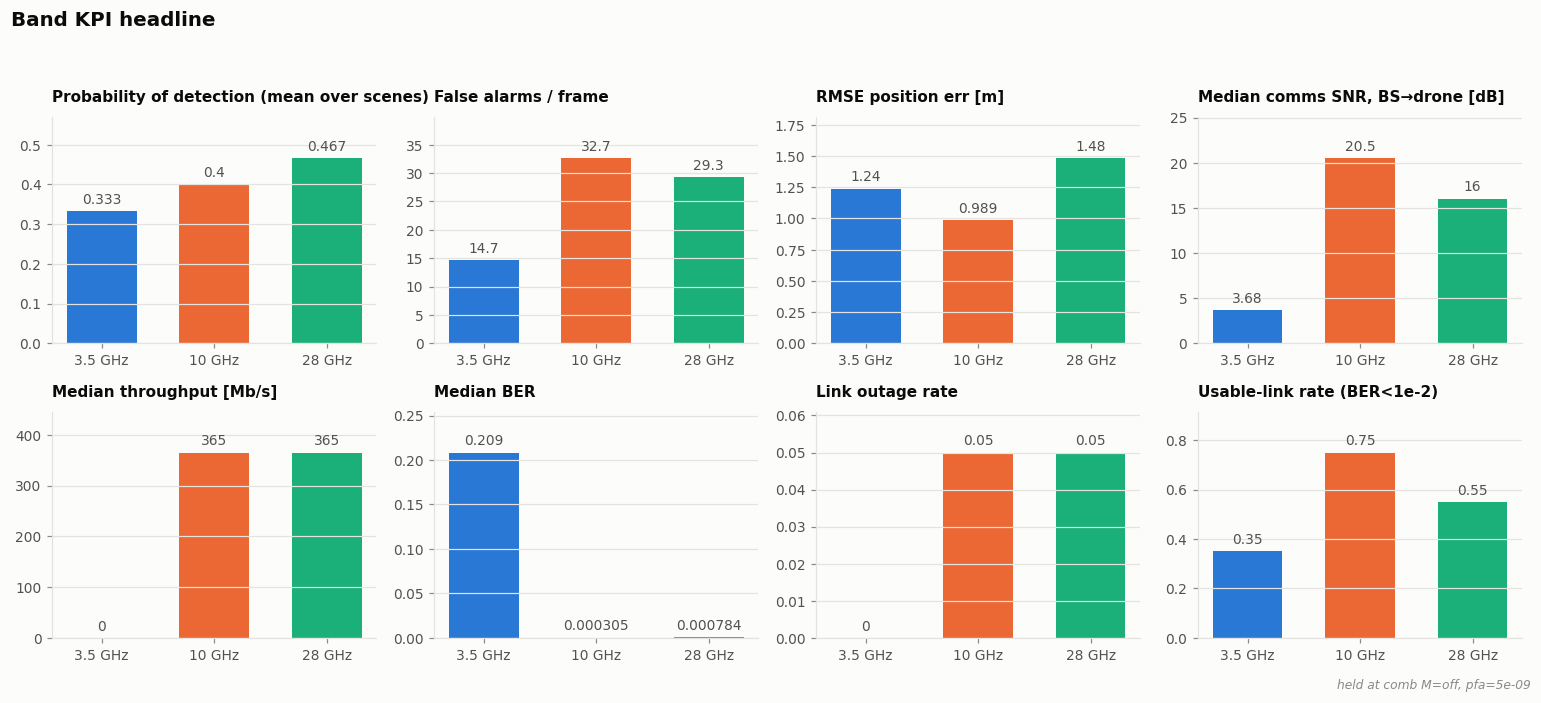

In [3]:
kpi = pd.DataFrame({
    'Probability of detection (mean over scenes)': scene.groupby('band')['prob_detection'].mean(),
    'False alarms / frame':       scene.groupby('band')['false_alarms_per_frame'].mean(),
    'RMSE position err [m]':      scene.groupby('band')['rmse_position_error_m'].mean(),
    'Median comms SNR, BS→drone [dB]': df.groupby('band')['snr'].median(),
    'Median throughput [Mb/s]':   df.groupby('band')['throughput_mbps'].median(),
    'Median BER':                 df.groupby('band')['ber'].median(),
    'Link outage rate':           df.groupby('band')['outage'].mean(),
    'Usable-link rate (BER<1e-2)':df.groupby('band')['link_ok'].mean(),
}).T
display(kpi.rename(columns=NAME).round(3))

fig, axes = plt.subplots(2, 4, figsize=(14, 6.2))
for ax, (label, row) in zip(axes.ravel(), kpi.iterrows()):
    vals = [row[b] for b in BANDS]
    bars = ax.bar([NAME[b] for b in BANDS], vals,
                  color=[COLOR[b] for b in BANDS], width=0.62)
    ax.bar_label(bars, fmt='%.3g', padding=3, color=INK_2, fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.margins(y=0.22)
    ax.grid(axis='x', visible=False)
fig.suptitle('Band KPI headline',
             x=0.008, ha='left', fontsize=13, weight='semibold', color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save(fig, '00_kpi_headline')

## 1. Communication link — SNR, BER, throughput

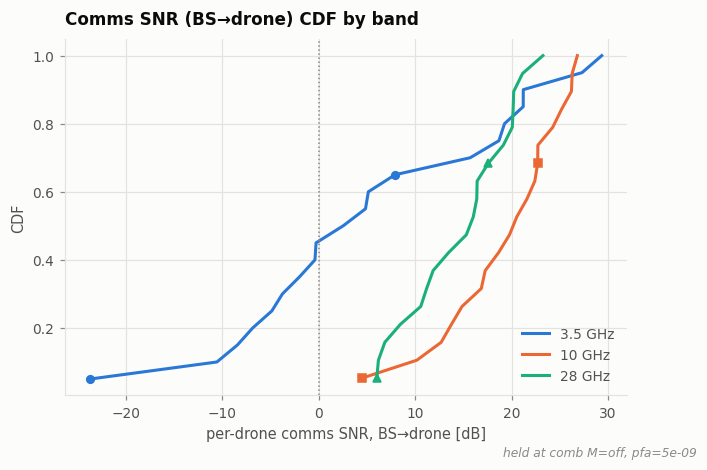

In [4]:
# 1a  SNR distribution: CDF per band
fig, ax = plt.subplots(figsize=(6.6, 4.2))
for b in BANDS:
    v, p = ecdf(df.loc[df.band == b, 'snr'])
    ax.plot(v, p, color=COLOR[b], label=NAME[b])
    ax.plot(v[::12], p[::12], MARK[b], color=COLOR[b], ms=5, ls='none')
ax.axvline(0, color=INK_MUTED, lw=1, ls=':')
ax.set_xlabel('per-drone comms SNR, BS→drone [dB]'); ax.set_ylabel('CDF')
ax.set_title('Comms SNR (BS→drone) CDF by band')
ax.legend(loc='lower right')
save(fig, '01a_snr_cdf')

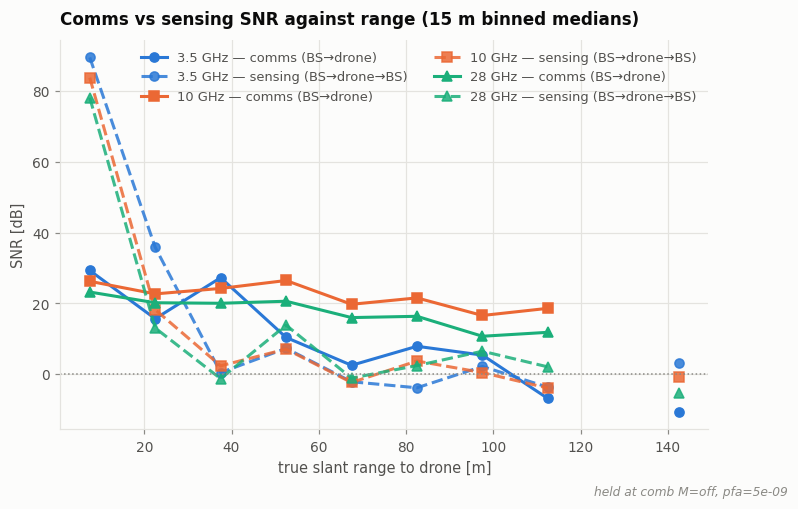

In [5]:
# 1b  SNR vs range, 15 m binned medians. Solid = comms (one-way, 1/R²); dashed =
# sensing (two-way, 1/R⁴, so twice the decay in dB).
fig, ax = plt.subplots(figsize=(7.6, 4.6))
bins = np.arange(0, 160, 15)
for b in BANDS:
    g = df[df.band == b]
    c, m, _ = binstat(g.true_range_m, g.snr, bins, 'median')
    ax.plot(c, m, color=COLOR[b], marker=MARK[b], ms=6,
            label=f'{NAME[b]} — comms (BS→drone)')
    c2, m2, _ = binstat(g.true_range_m, g.sensing_snr, bins, 'median')
    ax.plot(c2, m2, color=COLOR[b], marker=MARK[b], ms=6, ls='--', alpha=0.85,
            label=f'{NAME[b]} — sensing (BS→drone→BS)')
ax.axhline(0, color=INK_MUTED, lw=1, ls=':')
ax.set_xlabel('true slant range to drone [m]')
ax.set_ylabel('SNR [dB]')
ax.set_title('Comms vs sensing SNR against range (15 m binned medians)')
ax.legend(ncol=2, fontsize=8.5, loc='upper right')
save(fig, '01b_snr_vs_true_range')

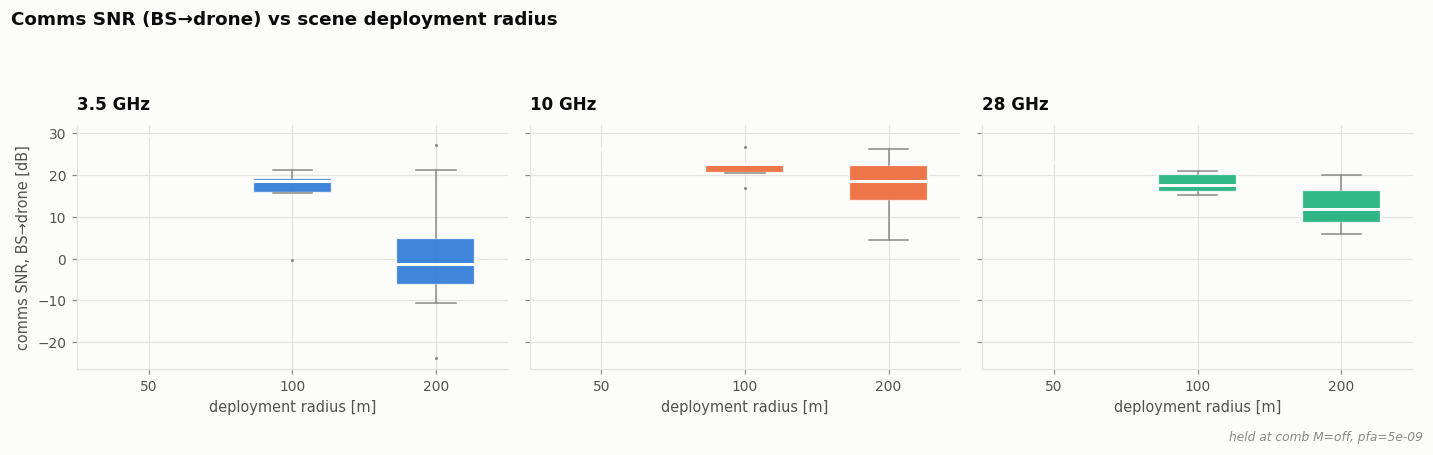

In [6]:
# 1c  SNR spread per deployment radius, small multiple per band
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), sharey=True)
radii = sorted(df.range_m.unique())
for ax, b in zip(axes, BANDS):
    g = df[df.band == b]
    data = [g.loc[g.range_m == r, 'snr'].dropna().values for r in radii]
    bp = ax.boxplot(data, positions=range(len(radii)), widths=0.55, patch_artist=True,
                    medianprops=dict(color=SURFACE, lw=2),
                    flierprops=dict(marker='.', markersize=4, markerfacecolor=INK_MUTED,
                                    markeredgecolor='none'))
    for patch in bp['boxes']:
        patch.set(facecolor=COLOR[b], edgecolor=SURFACE, linewidth=1.5, alpha=0.9)
    for w in bp['whiskers'] + bp['caps']:
        w.set(color=INK_MUTED, lw=1)
    ax.set_xticks(range(len(radii)), [f'{r}' for r in radii])
    ax.set_xlabel('deployment radius [m]')
    ax.set_title(NAME[b])
axes[0].set_ylabel('comms SNR, BS→drone [dB]')
fig.suptitle('Comms SNR (BS→drone) vs scene deployment radius', x=0.008, ha='left', fontsize=12,
             weight='semibold', color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.9])
save(fig, '01c_snr_by_radius_box')

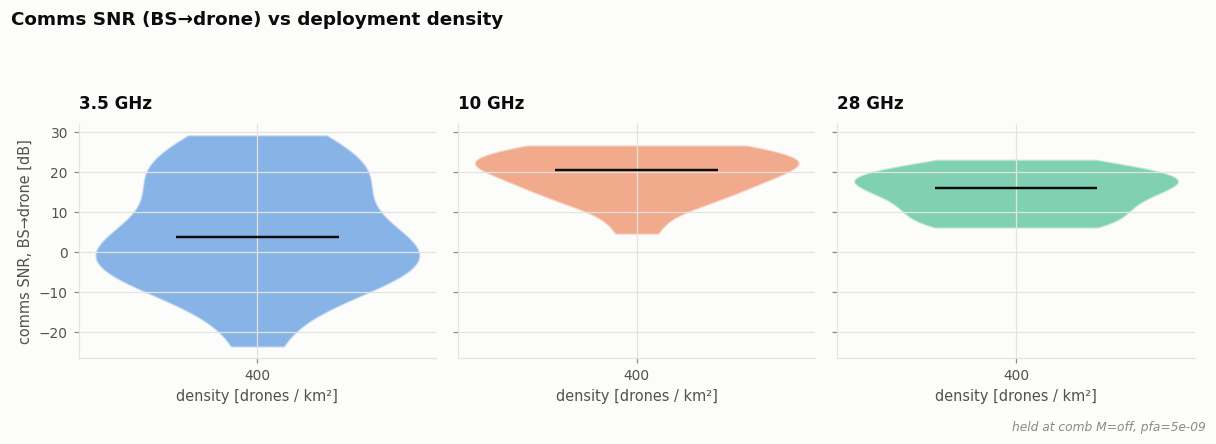

In [7]:
# 1d  SNR vs density, same layout
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), sharey=True)
dens = sorted(df.density_km2.unique())
for ax, b in zip(axes, BANDS):
    g = df[df.band == b]
    data = [g.loc[g.density_km2 == d, 'snr'].dropna().values for d in dens]
    parts = ax.violinplot(data, positions=range(len(dens)), widths=0.7, showextrema=False,
                          showmedians=True)
    for body in parts['bodies']:
        body.set(facecolor=COLOR[b], alpha=0.55, edgecolor=SURFACE, linewidth=1.5)
    parts['cmedians'].set(color=INK, lw=1.6)
    ax.set_xticks(range(len(dens)), [f'{d:g}' for d in dens])
    ax.set_xlabel('density [drones / km²]')
    ax.set_title(NAME[b])
axes[0].set_ylabel('comms SNR, BS→drone [dB]')
fig.suptitle('Comms SNR (BS→drone) vs deployment density', x=0.008, ha='left', fontsize=12,
             weight='semibold', color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.9])
save(fig, '01d_snr_by_density_violin')

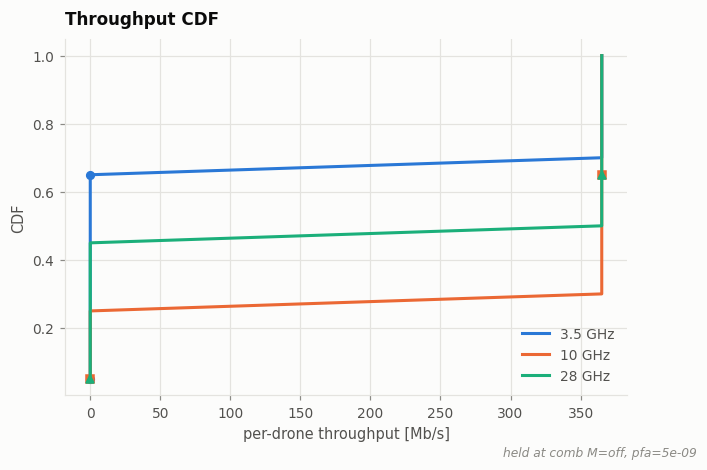

In [8]:
# 1e  Throughput CDF
fig, ax = plt.subplots(figsize=(6.6, 4.2))
for b in BANDS:
    v, p = ecdf(df.loc[df.band == b, 'throughput_mbps'])
    ax.plot(v, p, color=COLOR[b], label=NAME[b])
    ax.plot(v[::12], p[::12], MARK[b], color=COLOR[b], ms=5, ls='none')
ax.set_xlabel('per-drone throughput [Mb/s]'); ax.set_ylabel('CDF')
ax.set_title('Throughput CDF')
ax.legend(loc='lower right')
save(fig, '01e_throughput_cdf')

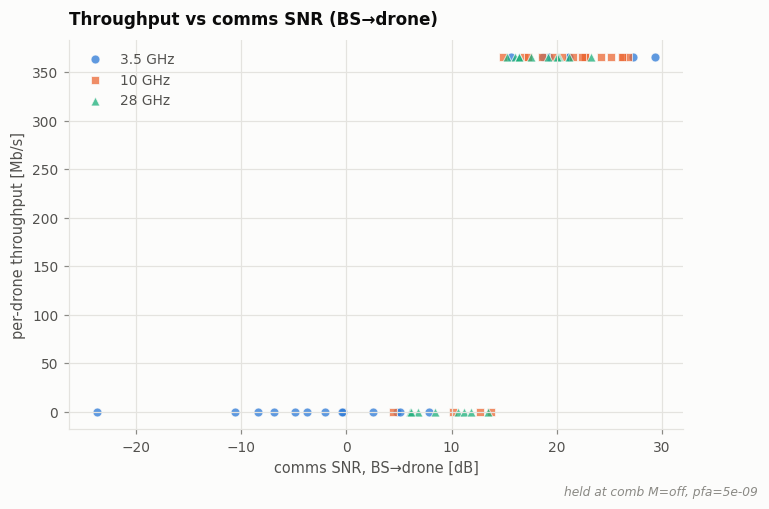

In [9]:
# 1f  Throughput vs SNR — the MCS staircase
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for b in BANDS:
    g = df[df.band == b]
    ax.scatter(g.snr, g.throughput_mbps, s=34, color=COLOR[b], marker=MARK[b],
               alpha=0.75, edgecolor=SURFACE, linewidth=0.6, label=NAME[b])
ax.set_xlabel('comms SNR, BS→drone [dB]'); ax.set_ylabel('per-drone throughput [Mb/s]')
ax.set_title('Throughput vs comms SNR (BS→drone)')
ax.legend(loc='upper left')
save(fig, '01f_throughput_vs_snr')

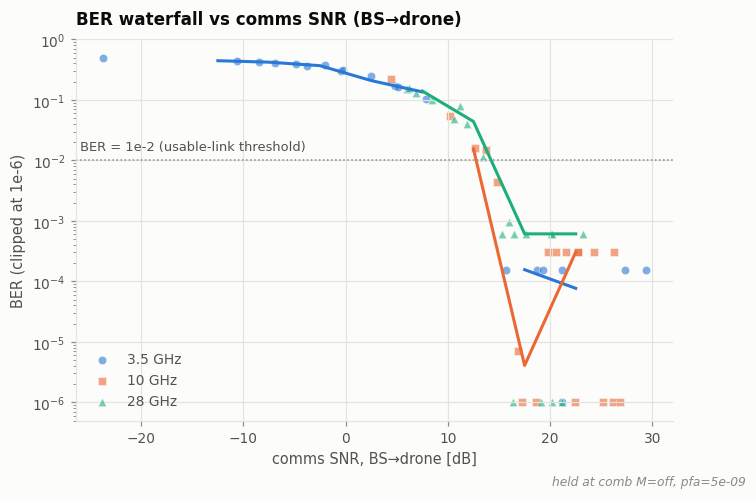

In [10]:
# 1g  BER vs SNR (log y)
fig, ax = plt.subplots(figsize=(7.0, 4.5))
for b in BANDS:
    g = df[df.band == b].sort_values('snr')
    y = g.ber.clip(lower=1e-6)
    ax.scatter(g.snr, y, s=30, color=COLOR[b], marker=MARK[b], alpha=0.6,
               edgecolor=SURFACE, linewidth=0.5, label=NAME[b])
    c, m, n = binstat(g.snr, y, np.arange(-60, 30, 5), 'median')
    ax.plot(c, m, color=COLOR[b], lw=2)
ax.set_yscale('log'); ax.set_ylim(5e-7, 1)
ax.axhline(1e-2, color=INK_MUTED, ls=':', lw=1)
ax.text(ax.get_xlim()[0], 1.3e-2, ' BER = 1e-2 (usable-link threshold)',
        color=INK_2, fontsize=8.5, va='bottom')
ax.set_xlabel('comms SNR, BS→drone [dB]'); ax.set_ylabel('BER (clipped at 1e-6)')
ax.set_title('BER waterfall vs comms SNR (BS→drone)')
ax.legend(loc='lower left')
save(fig, '01g_ber_vs_snr')

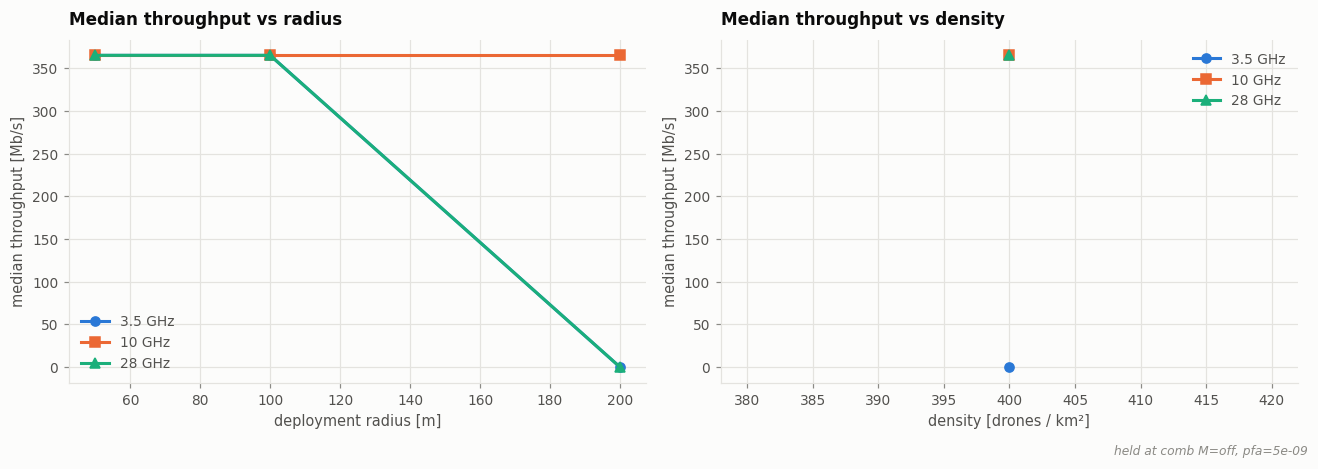

In [11]:
# 1h  Median throughput vs radius, and vs density
fig, axes = plt.subplots(1, 2, figsize=(12, 4.1))
for b in BANDS:
    g = df[df.band == b]
    s = g.groupby('range_m')['throughput_mbps'].median()
    axes[0].plot(s.index, s.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
    s2 = g.groupby('density_km2')['throughput_mbps'].median()
    axes[1].plot(s2.index, s2.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
axes[0].set_xlabel('deployment radius [m]'); axes[0].set_ylabel('median throughput [Mb/s]')
axes[0].set_title('Median throughput vs radius')
axes[1].set_xlabel('density [drones / km²]'); axes[1].set_ylabel('median throughput [Mb/s]')
axes[1].set_title('Median throughput vs density')
for ax in axes: ax.legend()
fig.tight_layout()
save(fig, '01h_throughput_vs_radius_density')

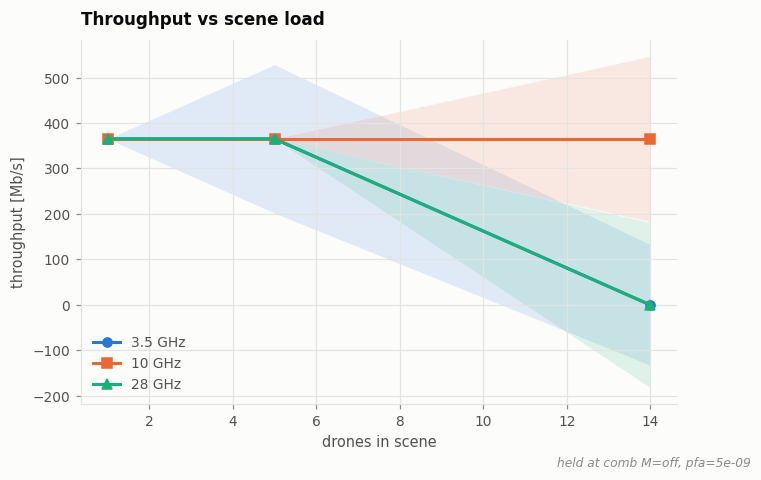

In [12]:
# 1i  Throughput vs number of drones in the scene
fig, ax = plt.subplots(figsize=(7.0, 4.3))
for b in BANDS:
    g = df[df.band == b]
    s = g.groupby('num_drones')['throughput_mbps'].agg(['median', 'std', 'size'])
    ax.plot(s.index, s['median'], color=COLOR[b], marker=MARK[b], label=NAME[b])
    ax.fill_between(s.index, s['median'] - s['std'].fillna(0),
                    s['median'] + s['std'].fillna(0), color=COLOR[b], alpha=0.13, lw=0)
ax.set_xlabel('drones in scene'); ax.set_ylabel('throughput [Mb/s]')
ax.set_title('Throughput vs scene load')
ax.legend()
save(fig, '01i_throughput_vs_num_drones')

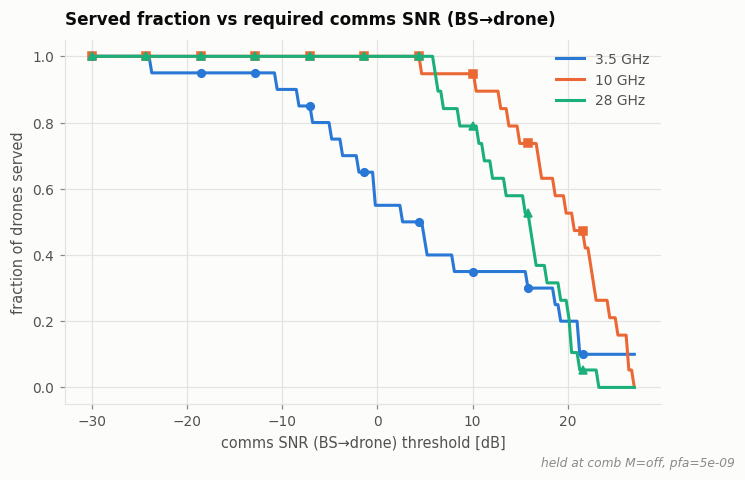

In [13]:
# 1j  Coverage curve: fraction of drones above an SNR threshold
fig, ax = plt.subplots(figsize=(7.0, 4.3))
th = np.linspace(-30, 27, 200)
for b in BANDS:
    v = df.loc[df.band == b, 'snr'].dropna().values
    frac = [(v >= t).mean() for t in th]
    ax.plot(th, frac, color=COLOR[b], label=NAME[b])
    ax.plot(th[::20], np.array(frac)[::20], MARK[b], color=COLOR[b], ms=5, ls='none')
ax.set_xlabel('comms SNR (BS→drone) threshold [dB]'); ax.set_ylabel('fraction of drones served')
ax.set_title('Served fraction vs required comms SNR (BS→drone)')
ax.legend()
save(fig, '01j_coverage_vs_snr_threshold')

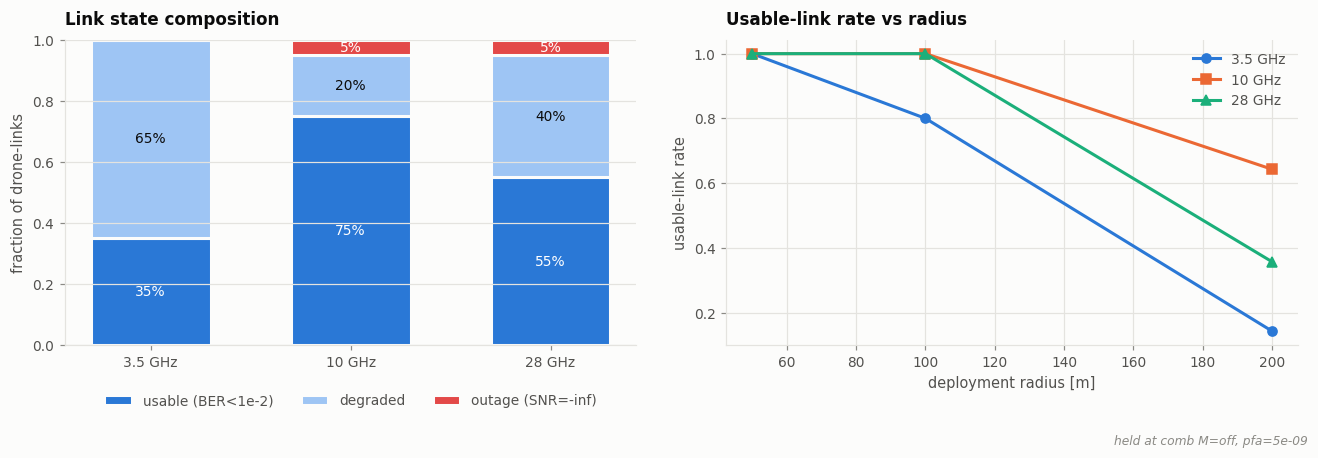

In [14]:
# 1k  Outage / usable-link stacked composition per band
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
cats = {'usable (BER<1e-2)': lambda g: g.link_ok.mean(),
        'degraded': lambda g: ((~g.link_ok) & (~g.outage)).mean(),
        'outage (SNR=-inf)': lambda g: g.outage.mean()}
shades = ['#2a78d6', '#9ec5f4', '#e34948']
bottom = np.zeros(len(BANDS))   # stacks over the bands PRESENT, not a fixed 3
for (lab, fn), sh in zip(cats.items(), shades):
    vals = np.array([fn(df[df.band == b]) for b in BANDS])
    axes[0].bar([NAME[b] for b in BANDS], vals, bottom=bottom, color=sh, width=0.6,
                edgecolor=SURFACE, linewidth=2, label=lab)
    for x, (v, bo) in enumerate(zip(vals, bottom)):
        if v > 0.04:
            axes[0].text(x, bo + v / 2, f'{v:.0%}', ha='center', va='center',
                         color='#ffffff' if sh != '#9ec5f4' else INK, fontsize=9)
    bottom += vals
axes[0].set_ylabel('fraction of drone-links'); axes[0].set_title('Link state composition')
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
axes[0].grid(axis='x', visible=False)

for b in BANDS:
    s = df[df.band == b].groupby('range_m')['link_ok'].mean()
    axes[1].plot(s.index, s.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
axes[1].set_xlabel('deployment radius [m]'); axes[1].set_ylabel('usable-link rate')
axes[1].set_title('Usable-link rate vs radius'); axes[1].legend()
fig.tight_layout()
save(fig, '01k_link_state_and_usable_rate')

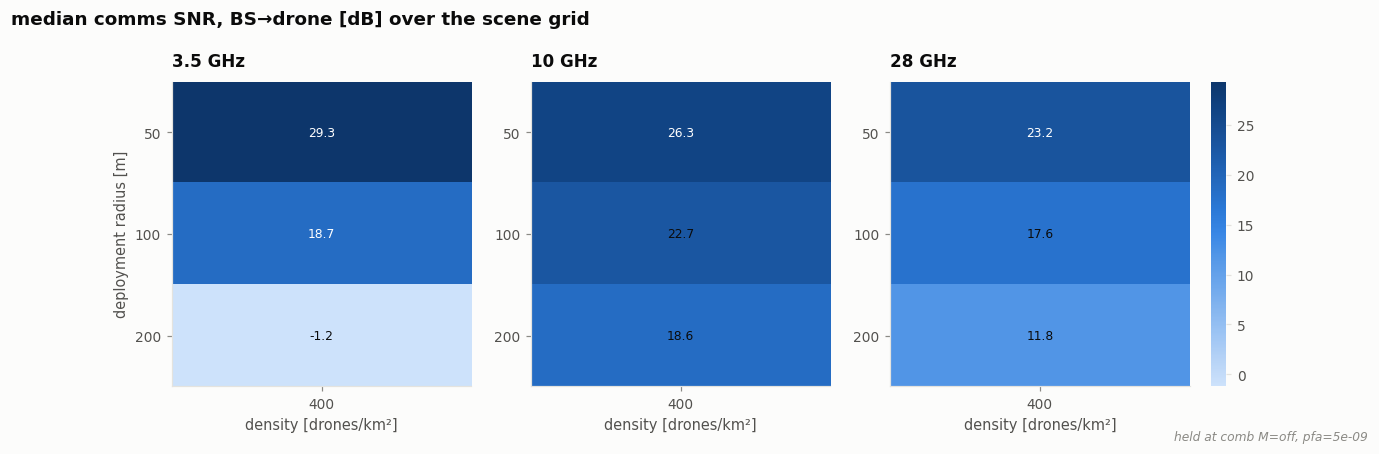

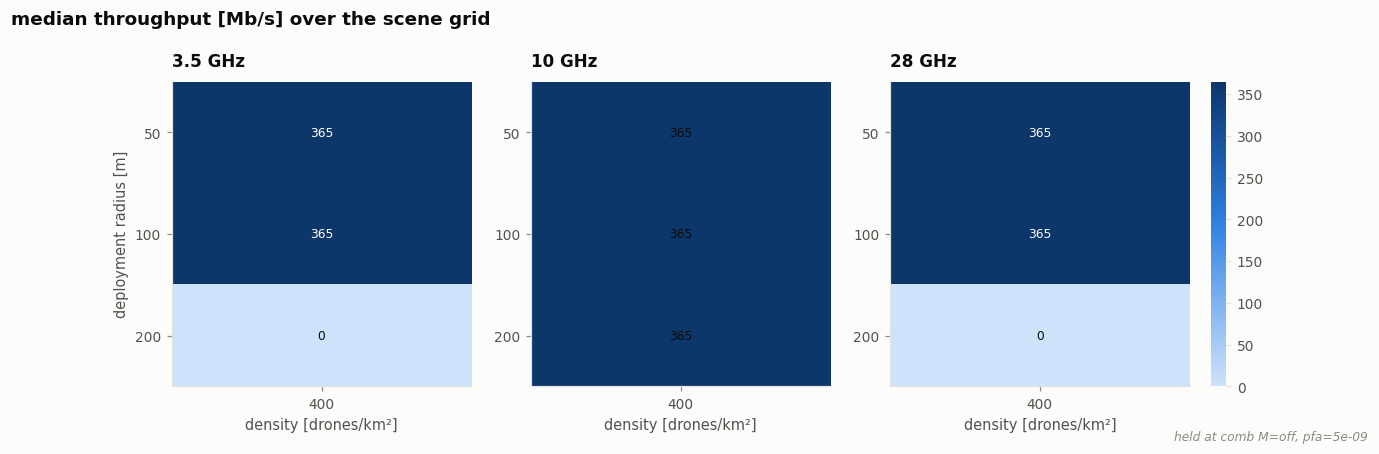

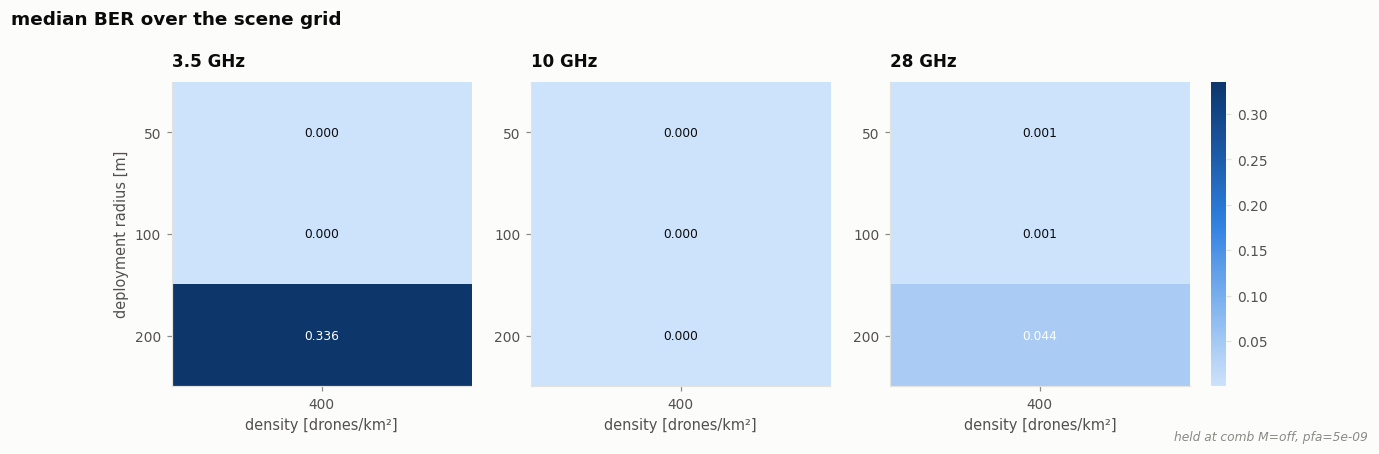

In [15]:
# 1l  Heatmaps: median SNR, throughput and BER over radius x density
HEAT_LABEL = {'snr': 'median comms SNR, BS→drone [dB]', 'throughput_mbps': 'median throughput [Mb/s]',
              'ber': 'median BER'}
for metric, fmt, name in [('snr', '{:.1f}', '01l_heat_snr'),
                          ('throughput_mbps', '{:.0f}', '01m_heat_throughput'),
                          ('ber', '{:.3f}', '01n_heat_ber')]:
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
    piv_all = [df[df.band == b].pivot_table(index='range_m', columns='density_km2',
                                            values=metric, aggfunc='median') for b in BANDS]
    vmin = min(np.nanmin(p.to_numpy(float)) for p in piv_all)
    vmax = max(np.nanmax(p.to_numpy(float)) for p in piv_all)
    for ax, b, piv in zip(axes, BANDS, piv_all):
        im = heat(ax, piv, fmt=fmt, vmin=vmin, vmax=vmax, title=NAME[b])
        ax.set_xlabel('density [drones/km²]')
    axes[0].set_ylabel('deployment radius [m]')
    cb = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
    cb.outline.set_visible(False); cb.ax.tick_params(color=GRID)
    lab = HEAT_LABEL[metric]
    fig.suptitle(lab + ' over the scene grid', x=0.008, y=1.06, ha='left', fontsize=12,
                 weight='semibold', color=INK)
    save(fig, name)

## 2. Sensing — detection, false alarms, position accuracy

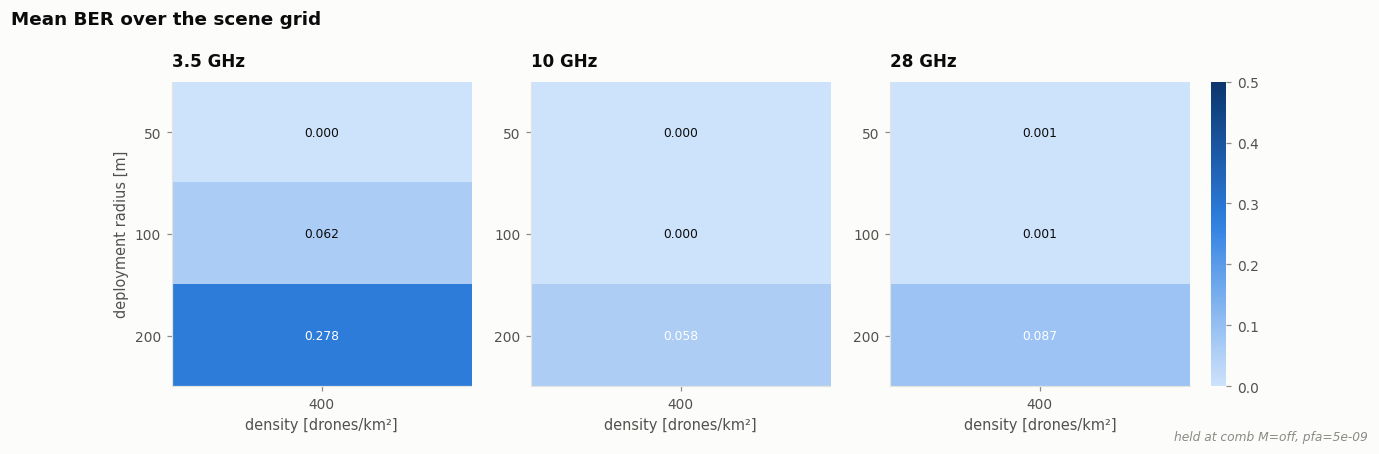

In [16]:
# 1n2  BER close-up: mean BER heatmap, and BER vs radius / density / population
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
pivs = [df[df.band == b].pivot_table(index='range_m', columns='density_km2', values='ber',
                                     aggfunc='mean') for b in BANDS]
for ax, b, piv in zip(axes, BANDS, pivs):
    im = heat(ax, piv, fmt='{:.3f}', vmin=0, vmax=0.5, title=NAME[b])
    ax.set_xlabel('density [drones/km²]')
axes[0].set_ylabel('deployment radius [m]')
cb = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02); cb.outline.set_visible(False)
fig.suptitle('Mean BER over the scene grid', x=0.008, y=1.06,
             ha='left', fontsize=12, weight='semibold', color=INK)
save(fig, '01o_heat_ber_mean')

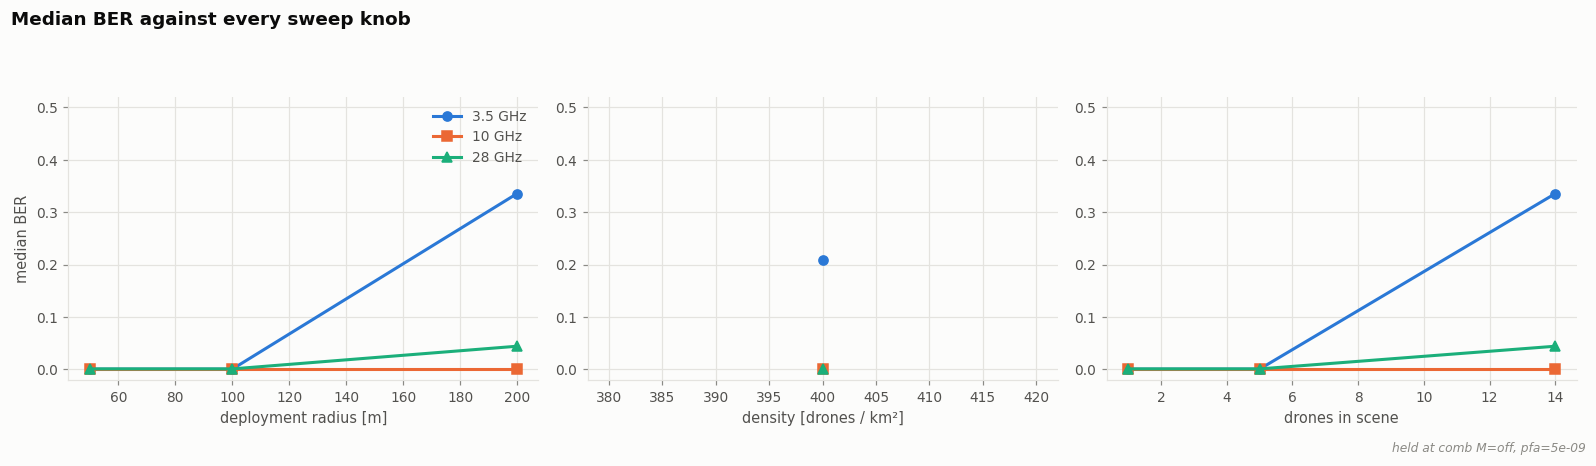

In [17]:
# 1p  BER trends: vs radius, vs density, vs scene population
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.0))
for b in BANDS:
    g = df[df.band == b]
    for ax, key, lab in zip(axes, ['range_m', 'density_km2', 'num_drones'],
                            ['deployment radius [m]', 'density [drones / km²]', 'drones in scene']):
        s = g.groupby(key)['ber'].median()
        ax.plot(s.index, s.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
        ax.set_xlabel(lab)
axes[0].set_ylabel('median BER')
for ax in axes:
    ax.set_ylim(-0.02, 0.52)
axes[0].legend()
fig.suptitle('Median BER against every sweep knob', x=0.008, ha='left', fontsize=12,
             weight='semibold', color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.9])
save(fig, '01q_ber_trends')

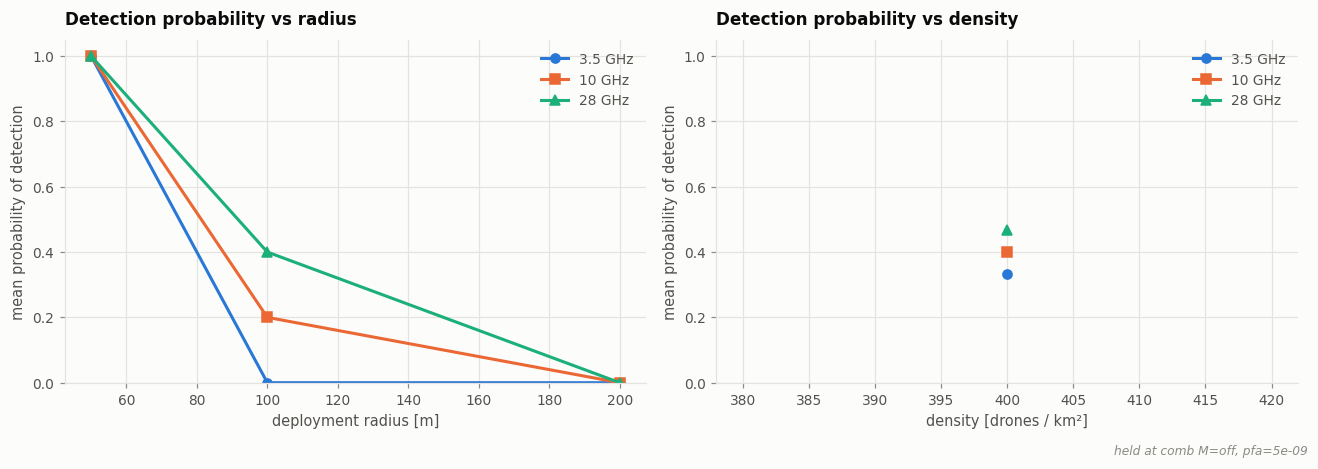

In [18]:
# 2a  Pd vs radius and vs density (scene-level)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.1))
for b in BANDS:
    g = scene[scene.band == b]
    s = g.groupby('range_m')['prob_detection'].mean()
    axes[0].plot(s.index, s.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
    s2 = g.groupby('density_km2')['prob_detection'].mean()
    axes[1].plot(s2.index, s2.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
axes[0].set_xlabel('deployment radius [m]'); axes[0].set_ylabel('mean probability of detection')
axes[0].set_title('Detection probability vs radius')
axes[1].set_xlabel('density [drones / km²]'); axes[1].set_ylabel('mean probability of detection')
axes[1].set_title('Detection probability vs density')
for ax in axes: ax.set_ylim(0, 1.05); ax.legend()
fig.tight_layout()
save(fig, '02a_pd_vs_radius_density')

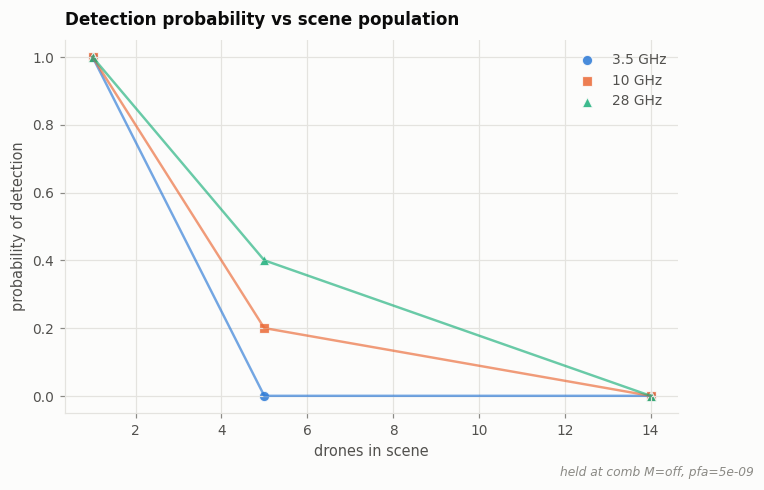

In [19]:
# 2b  Pd vs number of drones, log-x, with per-scene points
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for b in BANDS:
    g = scene[scene.band == b].sort_values('num_drones')
    ax.scatter(g.num_drones, g.prob_detection, s=46, color=COLOR[b], marker=MARK[b],
               alpha=0.85, edgecolor=SURFACE, linewidth=0.8, label=NAME[b])
    s = g.groupby('num_drones')['prob_detection'].mean()
    ax.plot(s.index, s.values, color=COLOR[b], lw=1.6, alpha=0.65)
ax.set_xlabel('drones in scene'); ax.set_ylabel('probability of detection')
ax.set_title('Detection probability vs scene population')
ax.legend()
save(fig, '02b_pd_vs_num_drones')

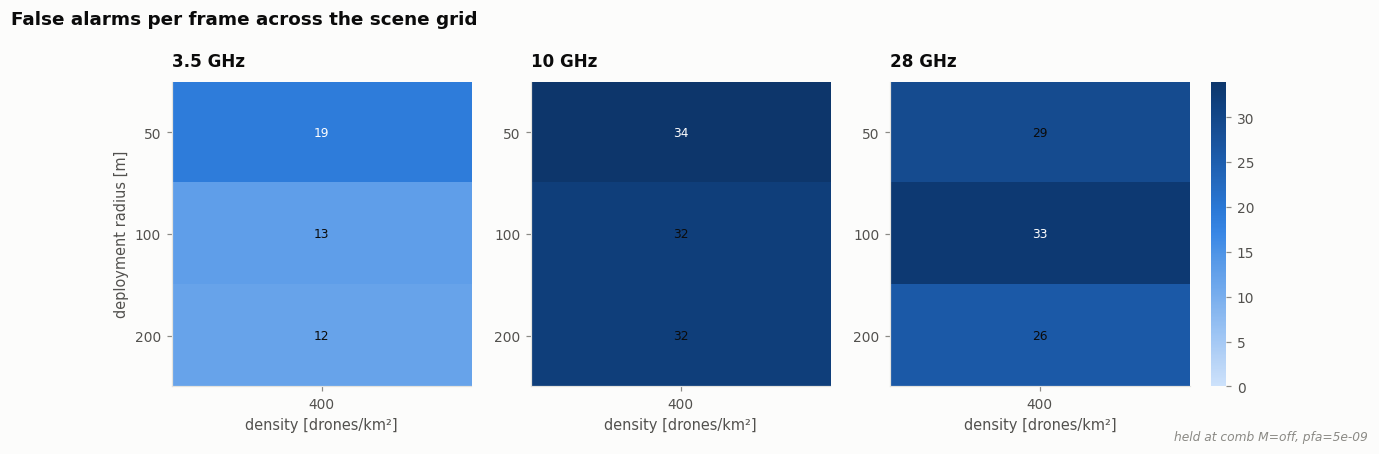

In [20]:
# 2c  False alarms per frame — scene grid heatmap + vs radius
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
pivs = [scene[scene.band == b].pivot_table(index='range_m', columns='density_km2',
                                           values='false_alarms_per_frame') for b in BANDS]
vmax = max(np.nanmax(p.to_numpy(float)) for p in pivs)
for ax, b, piv in zip(axes, BANDS, pivs):
    im = heat(ax, piv, fmt='{:.0f}', vmin=0, vmax=vmax, title=NAME[b])
    ax.set_xlabel('density [drones/km²]')
axes[0].set_ylabel('deployment radius [m]')
cb = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02); cb.outline.set_visible(False)
fig.suptitle('False alarms per frame across the scene grid', x=0.008, y=1.06, ha='left',
             fontsize=12, weight='semibold', color=INK)
save(fig, '02c_heat_false_alarms')

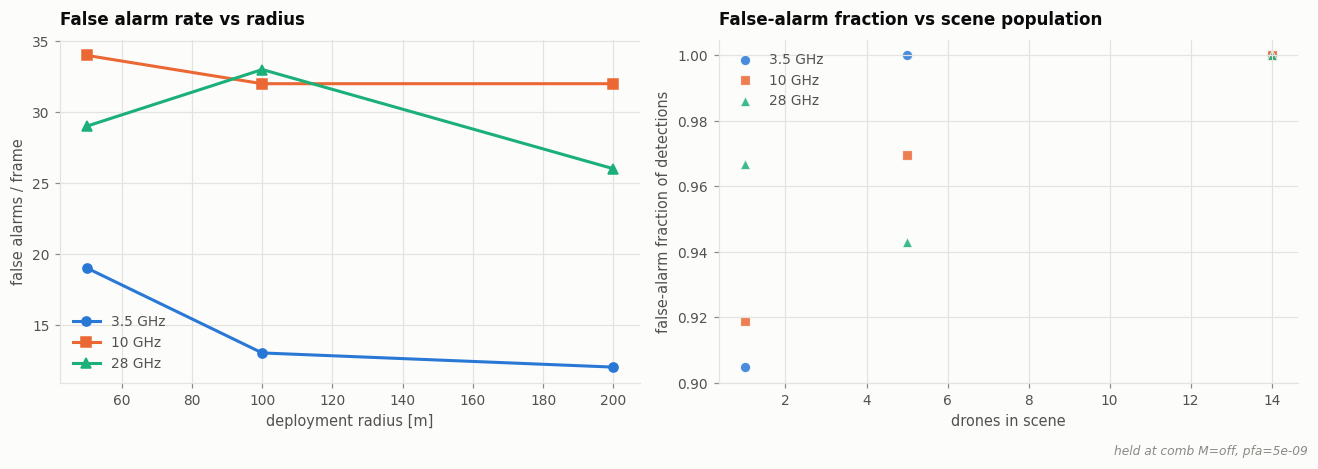

In [21]:
# 2d  False-alarm behaviour vs radius / vs population
fig, axes = plt.subplots(1, 2, figsize=(12, 4.1))
for b in BANDS:
    g = scene[scene.band == b]
    s = g.groupby('range_m')['false_alarms_per_frame'].mean()
    axes[0].plot(s.index, s.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
    gg = g.sort_values('num_drones')
    axes[1].scatter(gg.num_drones, gg.false_alarm_fraction, s=46, color=COLOR[b],
                    marker=MARK[b], alpha=0.85, edgecolor=SURFACE, linewidth=0.8,
                    label=NAME[b])
axes[0].set_xlabel('deployment radius [m]'); axes[0].set_ylabel('false alarms / frame')
axes[0].set_title('False alarm rate vs radius')
axes[1].set_xlabel('drones in scene'); axes[1].set_ylabel('false-alarm fraction of detections')
axes[1].set_title('False-alarm fraction vs scene population')
for ax in axes: ax.legend()
fig.tight_layout()
save(fig, '02d_false_alarms_vs_radius_population')

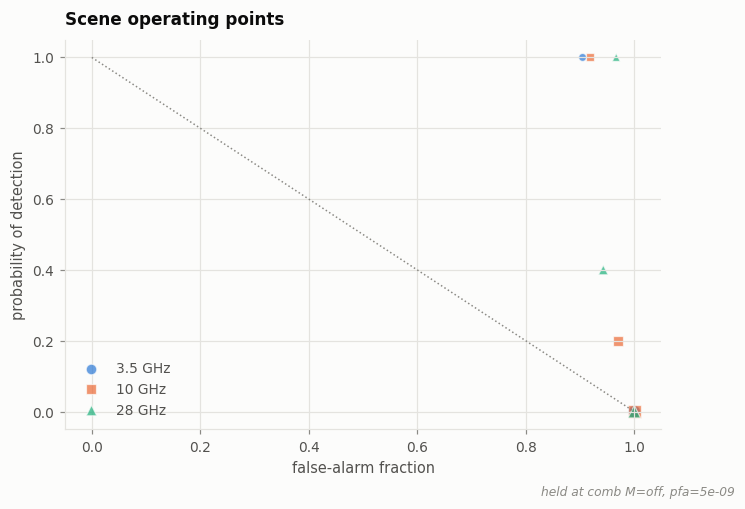

In [22]:
# 2e  Operating points: Pd vs false-alarm fraction (ROC-like cloud)
fig, ax = plt.subplots(figsize=(7.0, 4.6))
for b in BANDS:
    g = scene[scene.band == b].dropna(subset=['false_alarm_fraction'])
    sizes = 24 + 3.2 * g.num_drones
    ax.scatter(g.false_alarm_fraction, g.prob_detection, s=sizes, color=COLOR[b],
               marker=MARK[b], alpha=0.7, edgecolor=SURFACE, linewidth=0.8, label=NAME[b])
ax.plot([0, 1], [1, 0], color=INK_MUTED, ls=':', lw=1)
ax.set_xlabel('false-alarm fraction'); ax.set_ylabel('probability of detection')
ax.set_title('Scene operating points')
ax.legend()
save(fig, '02e_pd_vs_fa_operating_points')

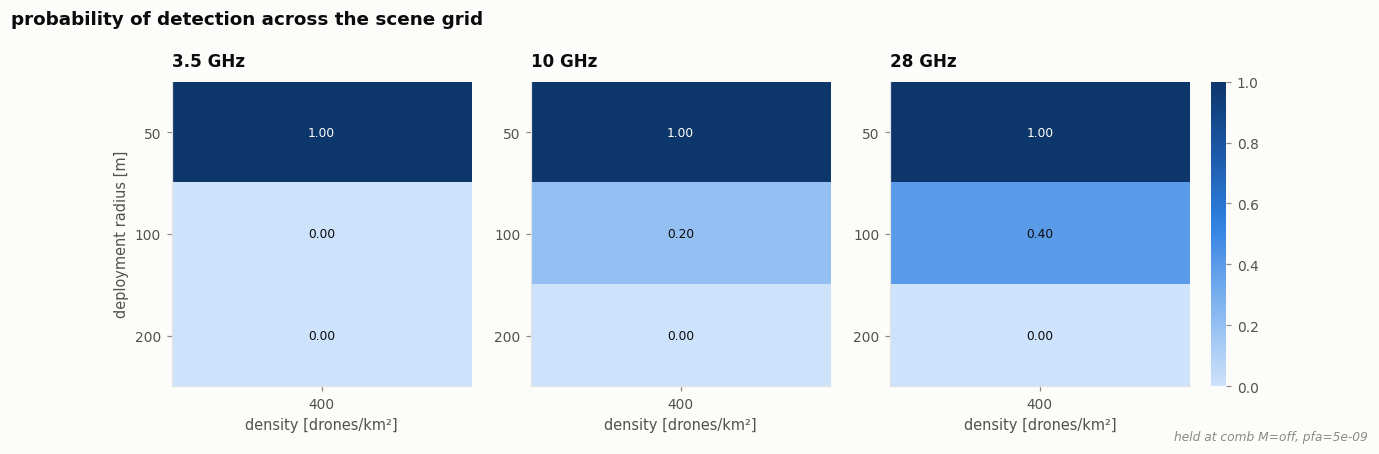

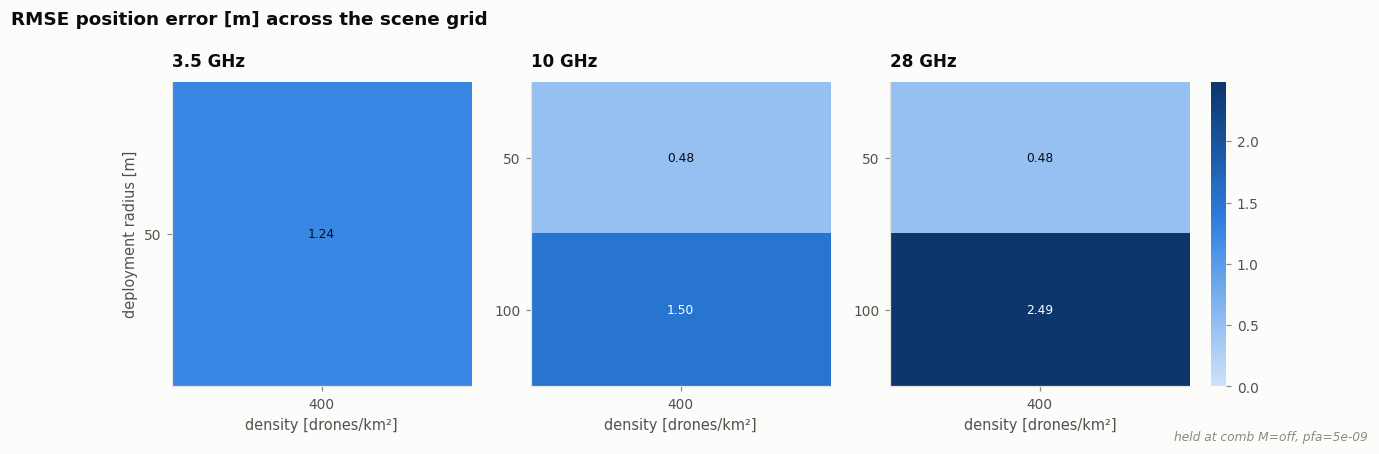

In [23]:
# 2f  Pd heatmap + RMSE heatmap on the scene grid
for metric, fmt, name, lab in [('prob_detection', '{:.2f}', '02f_heat_pd', 'probability of detection'),
                               ('rmse_position_error_m', '{:.2f}', '02g_heat_rmse',
                                'RMSE position error [m]')]:
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
    pivs = [scene[scene.band == b].pivot_table(index='range_m', columns='density_km2',
                                               values=metric) for b in BANDS]
    finite = [np.nanmax(p.to_numpy(float)) for p in pivs if np.isfinite(p.to_numpy(float)).any()]
    vmax = max(finite) if finite else 1
    for ax, b, piv in zip(axes, BANDS, pivs):
        im = heat(ax, piv, fmt=fmt, vmin=0, vmax=vmax, title=NAME[b])
        ax.set_xlabel('density [drones/km²]')
    axes[0].set_ylabel('deployment radius [m]')
    cb = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02); cb.outline.set_visible(False)
    fig.suptitle(f'{lab} across the scene grid', x=0.008, y=1.06,
                 ha='left', fontsize=12, weight='semibold', color=INK)
    save(fig, name)

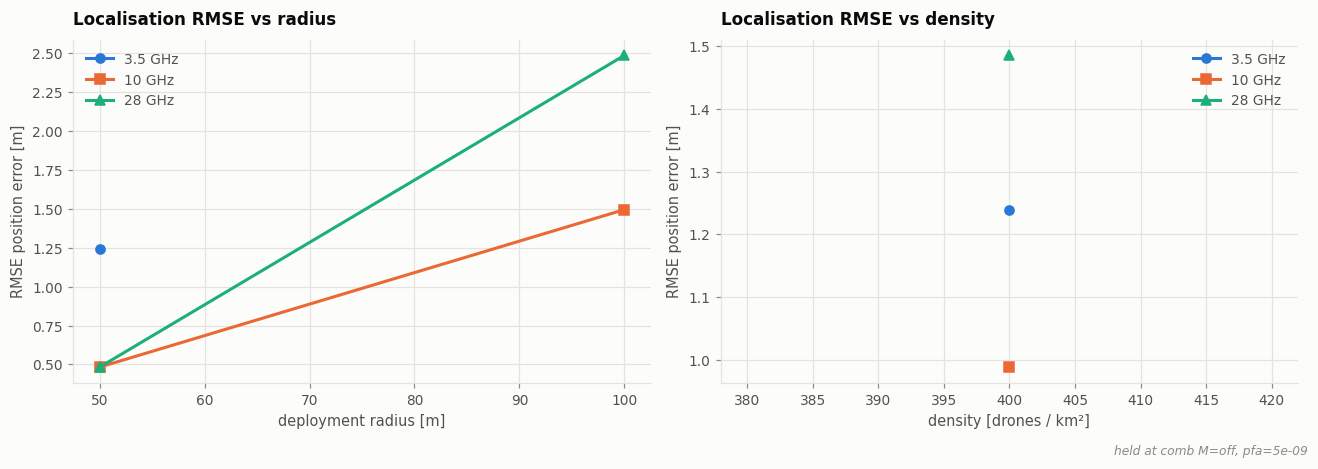

In [24]:
# 2h  RMSE position error vs radius and density
fig, axes = plt.subplots(1, 2, figsize=(12, 4.1))
for b in BANDS:
    g = scene[scene.band == b]
    s = g.groupby('range_m')['rmse_position_error_m'].mean()
    axes[0].plot(s.index, s.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
    s2 = g.groupby('density_km2')['rmse_position_error_m'].mean()
    axes[1].plot(s2.index, s2.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
axes[0].set_xlabel('deployment radius [m]'); axes[0].set_ylabel('RMSE position error [m]')
axes[0].set_title('Localisation RMSE vs radius')
axes[1].set_xlabel('density [drones / km²]'); axes[1].set_ylabel('RMSE position error [m]')
axes[1].set_title('Localisation RMSE vs density')
for ax in axes: ax.legend()
fig.tight_layout()
save(fig, '02h_rmse_vs_radius_density')

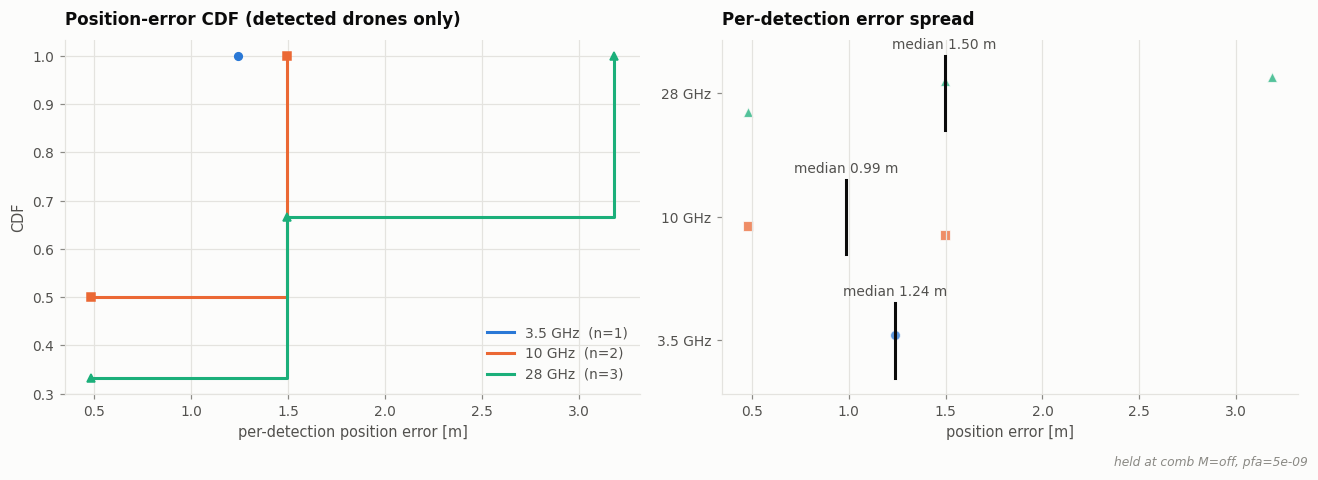

In [25]:
# 2i  Per-drone position error: CDF + strip plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for b in BANDS:
    v, p = ecdf(det.loc[det.band == b, 'position_error_m'])
    axes[0].step(v, p, where='post', color=COLOR[b], label=f'{NAME[b]}  (n={v.size})')
    axes[0].plot(v, p, MARK[b], color=COLOR[b], ms=5, ls='none')
axes[0].set_xlabel('per-detection position error [m]'); axes[0].set_ylabel('CDF')
axes[0].set_title('Position-error CDF (detected drones only)'); axes[0].legend(loc='lower right')

rng = np.random.default_rng(0)
for i, b in enumerate(BANDS):
    v = det.loc[det.band == b, 'position_error_m'].values
    axes[1].scatter(v, i + rng.uniform(-0.16, 0.16, v.size), s=42, color=COLOR[b],
                    marker=MARK[b], alpha=0.75, edgecolor=SURFACE, linewidth=0.7)
    axes[1].plot([np.median(v)] * 2, [i - 0.3, i + 0.3], color=INK, lw=2)
    axes[1].text(np.median(v), i + 0.36, f'median {np.median(v):.2f} m', color=INK_2,
                 fontsize=9, ha='center')
axes[1].set_yticks(range(len(BANDS)), [NAME[b] for b in BANDS])
axes[1].set_xlabel('position error [m]'); axes[1].set_title('Per-detection error spread')
axes[1].grid(axis='y', visible=False)
fig.tight_layout()
save(fig, '02i_position_error_cdf_strip')

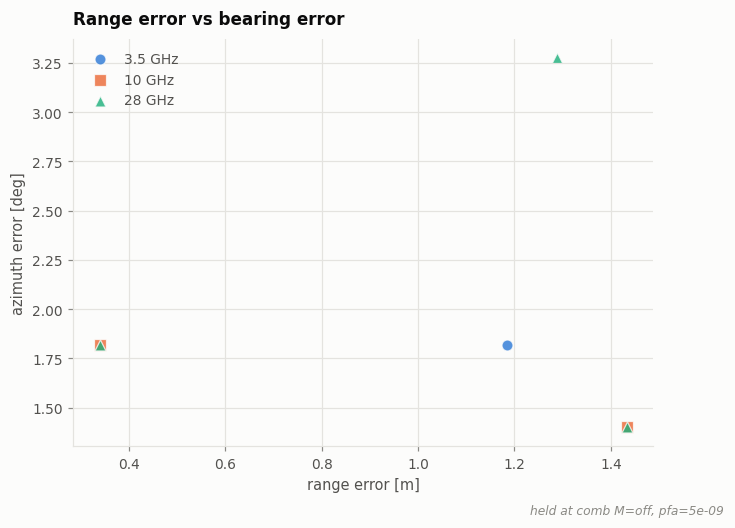

In [26]:
# 2j  Error decomposition: range error vs azimuth error
fig, ax = plt.subplots(figsize=(6.8, 4.8))
for b in BANDS:
    g = det[det.band == b]
    ax.scatter(g.range_error_m, g.azimuth_error_deg, s=52, color=COLOR[b], marker=MARK[b],
               alpha=0.8, edgecolor=SURFACE, linewidth=0.8, label=NAME[b])
ax.set_xlabel('range error [m]'); ax.set_ylabel('azimuth error [deg]')
ax.set_title('Range error vs bearing error')
ax.legend()
save(fig, '02j_range_vs_azimuth_error')

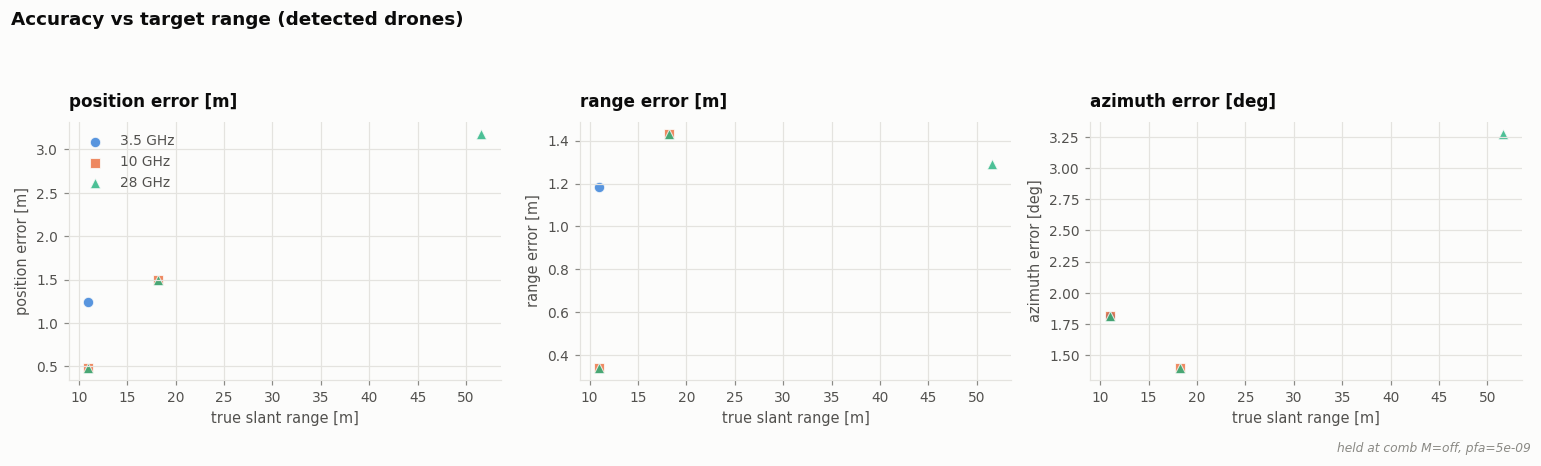

In [27]:
# 2k  Position / range / azimuth error vs true range
fig, axes = plt.subplots(1, 3, figsize=(14, 4.0), sharex=True)
for ax, col, lab in zip(axes,
        ['position_error_m', 'range_error_m', 'azimuth_error_deg'],
        ['position error [m]', 'range error [m]', 'azimuth error [deg]']):
    for b in BANDS:
        g = det[det.band == b]
        ax.scatter(g.true_range_m, g[col], s=46, color=COLOR[b], marker=MARK[b],
                   alpha=0.78, edgecolor=SURFACE, linewidth=0.7, label=NAME[b])
    ax.set_xlabel('true slant range [m]'); ax.set_ylabel(lab); ax.set_title(lab)
axes[0].legend()
fig.suptitle('Accuracy vs target range (detected drones)', x=0.008, ha='left',
             fontsize=12, weight='semibold', color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.91])
save(fig, '02k_errors_vs_true_range')

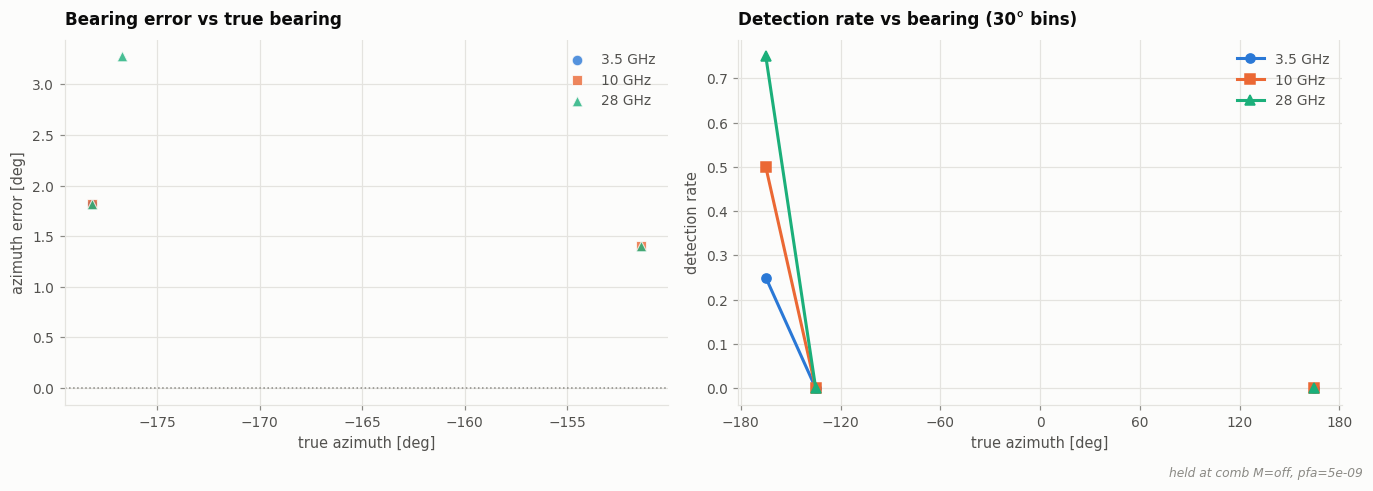

In [28]:
# 2l  Azimuth error vs true azimuth — bearing-dependent bias?
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
for b in BANDS:
    g = det[det.band == b]
    axes[0].scatter(g.true_azimuth_deg, g.azimuth_error_deg, s=48, color=COLOR[b],
                    marker=MARK[b], alpha=0.8, edgecolor=SURFACE, linewidth=0.7, label=NAME[b])
axes[0].axhline(0, color=INK_MUTED, lw=1, ls=':')
axes[0].set_xlabel('true azimuth [deg]'); axes[0].set_ylabel('azimuth error [deg]')
axes[0].set_title('Bearing error vs true bearing'); axes[0].legend()

bins = np.arange(-180, 181, 30)
for b in BANDS:
    g = df[df.band == b]
    c, m, n = binstat(g.true_azimuth_deg, g.detected.astype(float), bins, 'mean')
    axes[1].plot(c, m, color=COLOR[b], marker=MARK[b], label=NAME[b])
axes[1].set_xlabel('true azimuth [deg]'); axes[1].set_ylabel('detection rate')
axes[1].set_title('Detection rate vs bearing (30° bins)'); axes[1].legend()
axes[1].set_xticks(np.arange(-180, 181, 60))
fig.tight_layout()
save(fig, '02l_azimuth_dependence')

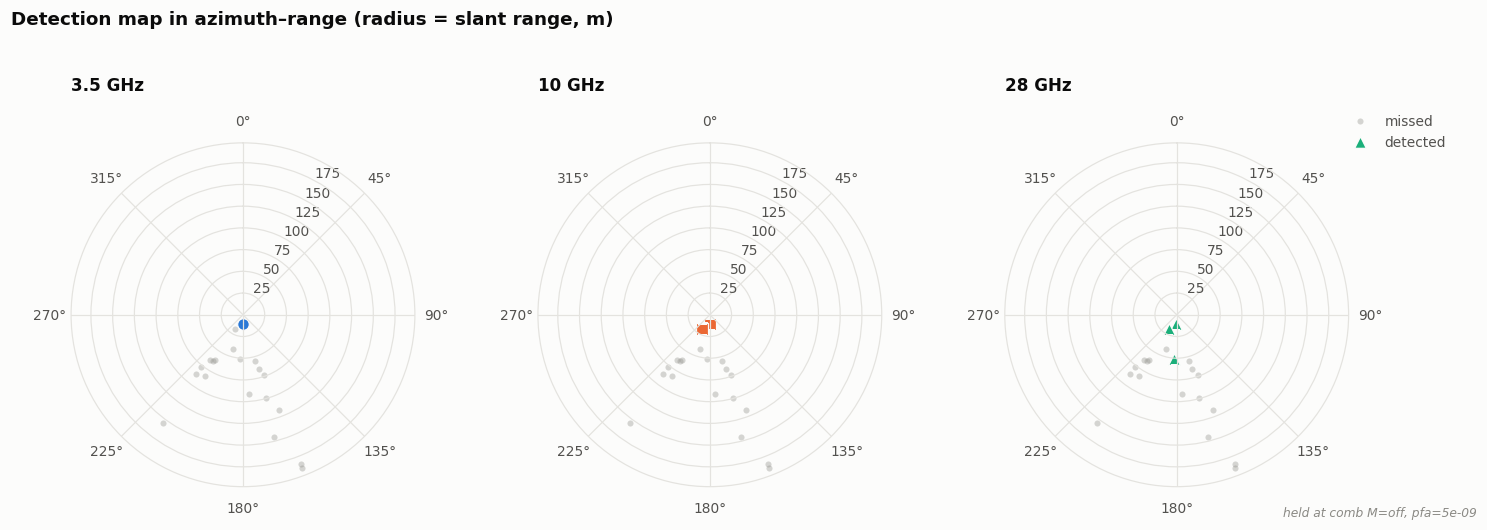

In [29]:
# 2m  Polar view: where in the sector do detections happen
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), subplot_kw=dict(projection='polar'))
for ax, b in zip(axes, BANDS):
    g = df[df.band == b]
    miss, hit = g[~g.detected], g[g.detected]
    ax.scatter(np.deg2rad(miss.true_azimuth_deg), miss.true_range_m, s=16,
               color=INK_MUTED, alpha=0.35, linewidths=0, label='missed')
    ax.scatter(np.deg2rad(hit.true_azimuth_deg), hit.true_range_m, s=58, color=COLOR[b],
               marker=MARK[b], edgecolor=SURFACE, linewidth=0.8, label='detected')
    ax.set_title(NAME[b], pad=16)
    ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)
    ax.grid(color=GRID)
    ax.set_rlabel_position(28)
axes[-1].legend(loc='upper right', bbox_to_anchor=(1.32, 1.12))
fig.suptitle('Detection map in azimuth–range (radius = slant range, m)', x=0.008,
             ha='left', fontsize=12, weight='semibold', color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.9])
save(fig, '02m_polar_detection_map')

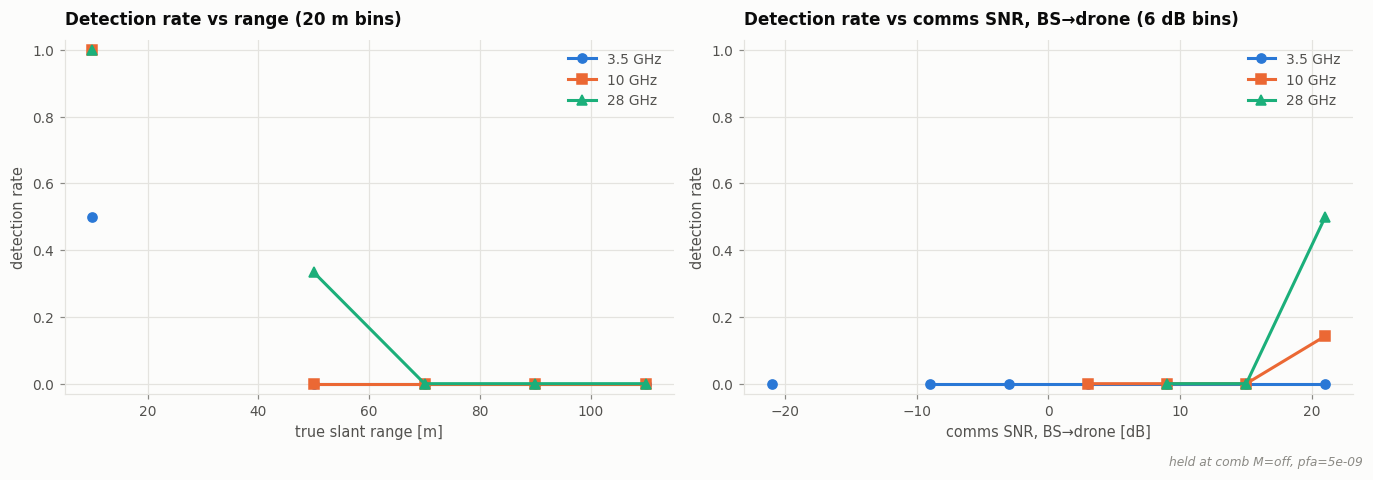

In [30]:
# 2n  Detection rate vs range and vs SNR (binned, per band)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
rbins = np.arange(0, 160, 20)
for b in BANDS:
    g = df[df.band == b]
    c, m, n = binstat(g.true_range_m, g.detected.astype(float), rbins, 'mean')
    axes[0].plot(c, m, color=COLOR[b], marker=MARK[b], label=NAME[b])
    sbins = np.arange(-30, 30, 6)
    c2, m2, n2 = binstat(g.snr, g.detected.astype(float), sbins, 'mean')
    axes[1].plot(c2, m2, color=COLOR[b], marker=MARK[b], label=NAME[b])
axes[0].set_xlabel('true slant range [m]'); axes[0].set_ylabel('detection rate')
axes[0].set_title('Detection rate vs range (20 m bins)')
axes[1].set_xlabel('comms SNR, BS→drone [dB]'); axes[1].set_ylabel('detection rate')
axes[1].set_title('Detection rate vs comms SNR, BS→drone (6 dB bins)')
for ax in axes: ax.set_ylim(-0.03, 1.03); ax.legend()
fig.tight_layout()
save(fig, '02n_detection_rate_vs_range_snr')

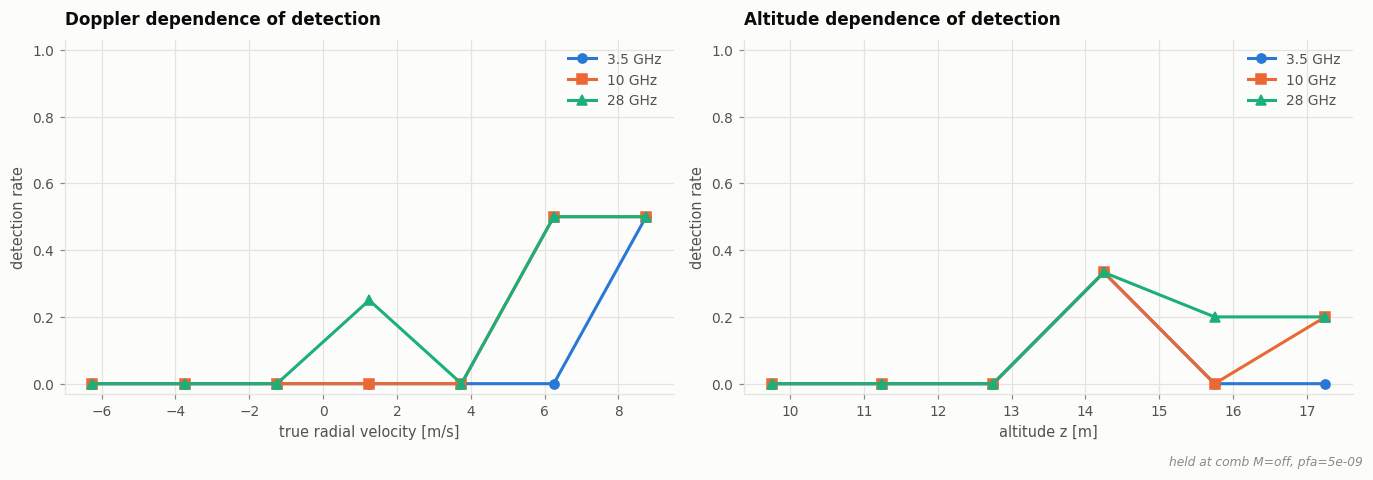

In [31]:
# 2o  Detection vs kinematics: radial velocity and altitude
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
vbins = np.arange(-10, 11, 2.5)
for b in BANDS:
    g = df[df.band == b]
    c, m, n = binstat(g.true_radial_velocity_mps, g.detected.astype(float), vbins, 'mean')
    axes[0].plot(c, m, color=COLOR[b], marker=MARK[b], label=NAME[b])
    zb = np.arange(9, 19, 1.5)
    c2, m2, n2 = binstat(g.z, g.detected.astype(float), zb, 'mean')
    axes[1].plot(c2, m2, color=COLOR[b], marker=MARK[b], label=NAME[b])
axes[0].set_xlabel('true radial velocity [m/s]'); axes[0].set_ylabel('detection rate')
axes[0].set_title('Doppler dependence of detection')
axes[1].set_xlabel('altitude z [m]'); axes[1].set_ylabel('detection rate')
axes[1].set_title('Altitude dependence of detection')
for ax in axes: ax.set_ylim(-0.03, 1.03); ax.legend()
fig.tight_layout()
save(fig, '02o_detection_vs_kinematics')

## 3. Cross-band, paired

Same seeds, same drones — so the bands can be differenced drone-by-drone instead of
compared only in aggregate. Join key is `(scene_id, drone_id)`.

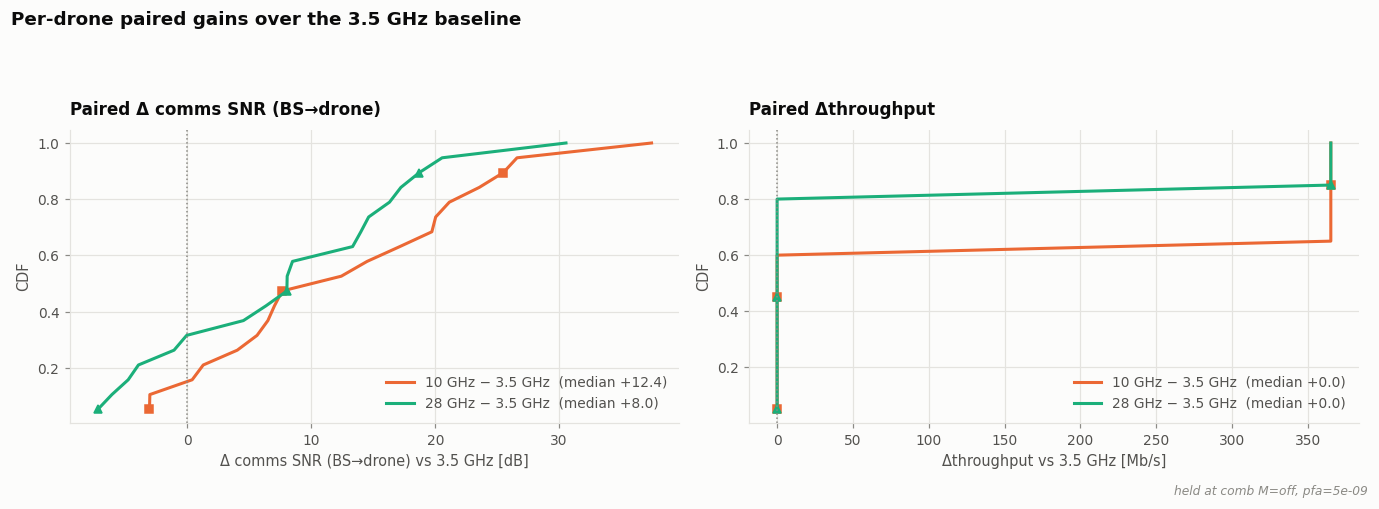

In [32]:
# Cross-band comparison: needs at least two bands in the csv.
if len(BANDS) < 2:
    print(f'skipped: only {len(BANDS)} band in this sweep '
          f'({[NAME[b] for b in BANDS]}) -- this plot compares bands')
else:
    piv = df.pivot_table(index=['scene_id', 'drone_id'], columns='band',
                         values=['snr', 'throughput_mbps', 'ber', 'true_range_m'],
                         aggfunc='first')

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    for ax, metric, lab in zip(axes, ['snr', 'throughput_mbps'],
                               [f'Δ comms SNR (BS→drone) vs {NAME[BASE]} [dB]', f'Δthroughput vs {NAME[BASE]} [Mb/s]']):
        for b in OTHERS:
            d = (piv[metric][b] - piv[metric][BASE]).dropna()
            v, p = ecdf(d)
            ax.plot(v, p, color=COLOR[b], label=f'{NAME[b]} − {NAME[BASE]}  (median {np.median(d):+.1f})')
            ax.plot(v[::8], p[::8], MARK[b], color=COLOR[b], ms=5, ls='none')
        ax.axvline(0, color=INK_MUTED, ls=':', lw=1)
        ax.set_xlabel(lab); ax.set_ylabel('CDF'); ax.legend(loc='lower right')
        ax.set_title('Paired ' + lab.split(' vs')[0])
    fig.suptitle(f'Per-drone paired gains over the {NAME[BASE]} baseline', x=0.008, ha='left',
                 fontsize=12, weight='semibold', color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    save(fig, '03a_paired_deltas_cdf')


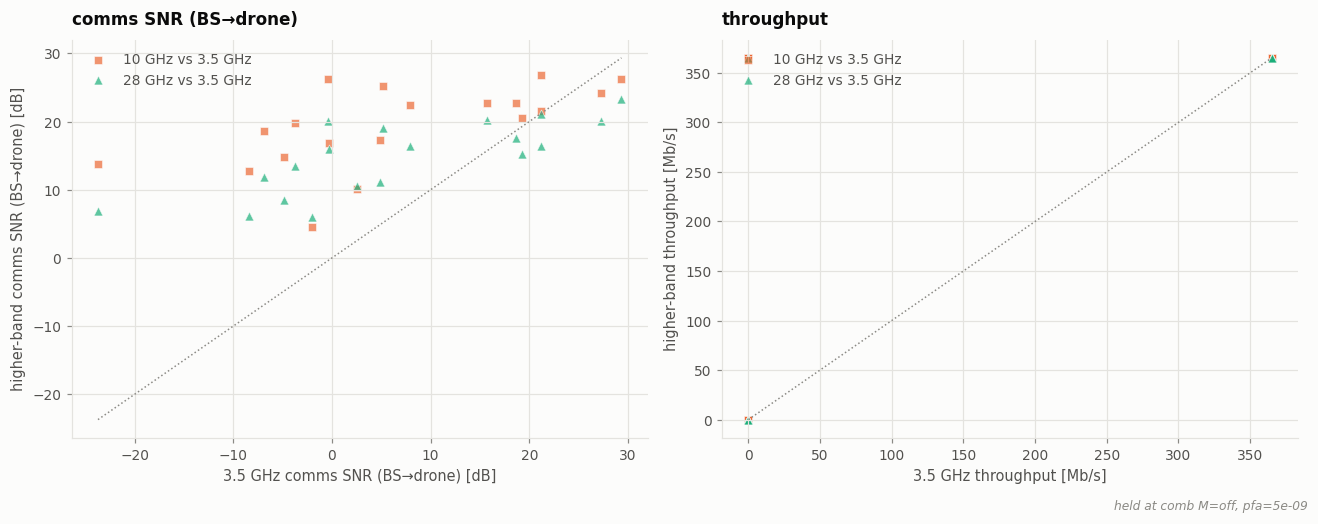

In [33]:
# Cross-band comparison: needs at least two bands in the csv (and `piv`, built by
# the paired-deltas cell above, which is itself skipped on a single-band sweep).
if len(BANDS) < 2:
    print(f'skipped: only {len(BANDS)} band in this sweep '
          f'({[NAME[b] for b in BANDS]}) -- this plot compares bands')
else:
    # 3b  Direct band-vs-band scatter with the identity line
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    for ax, metric, lab, unit in zip(axes, ['snr', 'throughput_mbps'],
                                     ['comms SNR (BS→drone)', 'throughput'], ['dB', 'Mb/s']):
        base = piv[metric][BASE]
        rest = [piv[metric][b] for b in OTHERS]
        lim = [np.nanmin([base.min()] + [r.min() for r in rest]),
               np.nanmax([base.max()] + [r.max() for r in rest])]
        ax.plot(lim, lim, color=INK_MUTED, ls=':', lw=1)
        for b in OTHERS:
            ax.scatter(base, piv[metric][b], s=34, color=COLOR[b], marker=MARK[b], alpha=0.7,
                       edgecolor=SURFACE, linewidth=0.5, label=f'{NAME[b]} vs {NAME[BASE]}')
        ax.set_xlabel(f'{NAME[BASE]} {lab} [{unit}]'); ax.set_ylabel(f'higher-band {lab} [{unit}]')
        ax.set_title(lab)
        ax.legend(loc='upper left')
    fig.tight_layout()
    save(fig, '03b_band_vs_band_scatter')


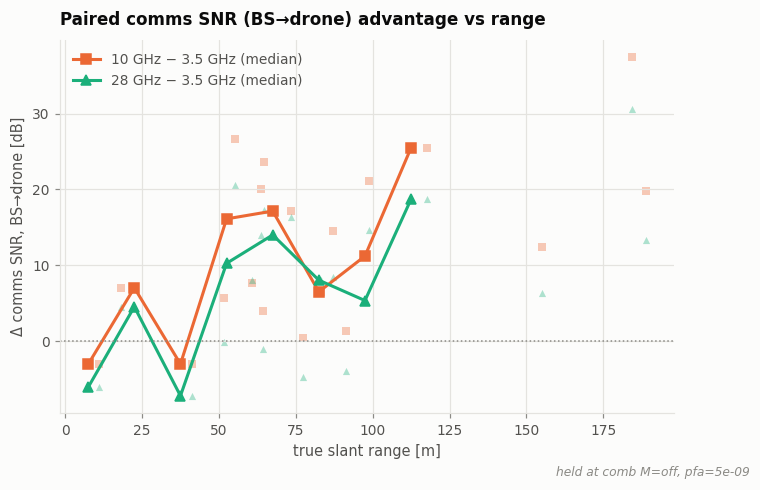

In [34]:
# Cross-band comparison: needs at least two bands in the csv.
if len(BANDS) < 2:
    print(f'skipped: only {len(BANDS)} band in this sweep '
          f'({[NAME[b] for b in BANDS]}) -- this plot compares bands')
else:
    # 3c  Paired ΔSNR vs range — does the higher-band advantage survive distance?
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    rng_base = piv['true_range_m'][BASE]
    bins = np.arange(0, 160, 15)
    for b in OTHERS:
        d = piv['snr'][b] - piv['snr'][BASE]
        ax.scatter(rng_base, d, s=22, color=COLOR[b], marker=MARK[b], alpha=0.35, linewidths=0)
        c, m, n = binstat(rng_base, d, bins, 'median')
        ax.plot(c, m, color=COLOR[b], marker=MARK[b], label=f'{NAME[b]} − {NAME[BASE]} (median)')
    ax.axhline(0, color=INK_MUTED, ls=':', lw=1)
    ax.set_xlabel('true slant range [m]'); ax.set_ylabel('Δ comms SNR, BS→drone [dB]')
    ax.set_title('Paired comms SNR (BS→drone) advantage vs range')
    ax.legend()
    save(fig, '03c_delta_snr_vs_range')


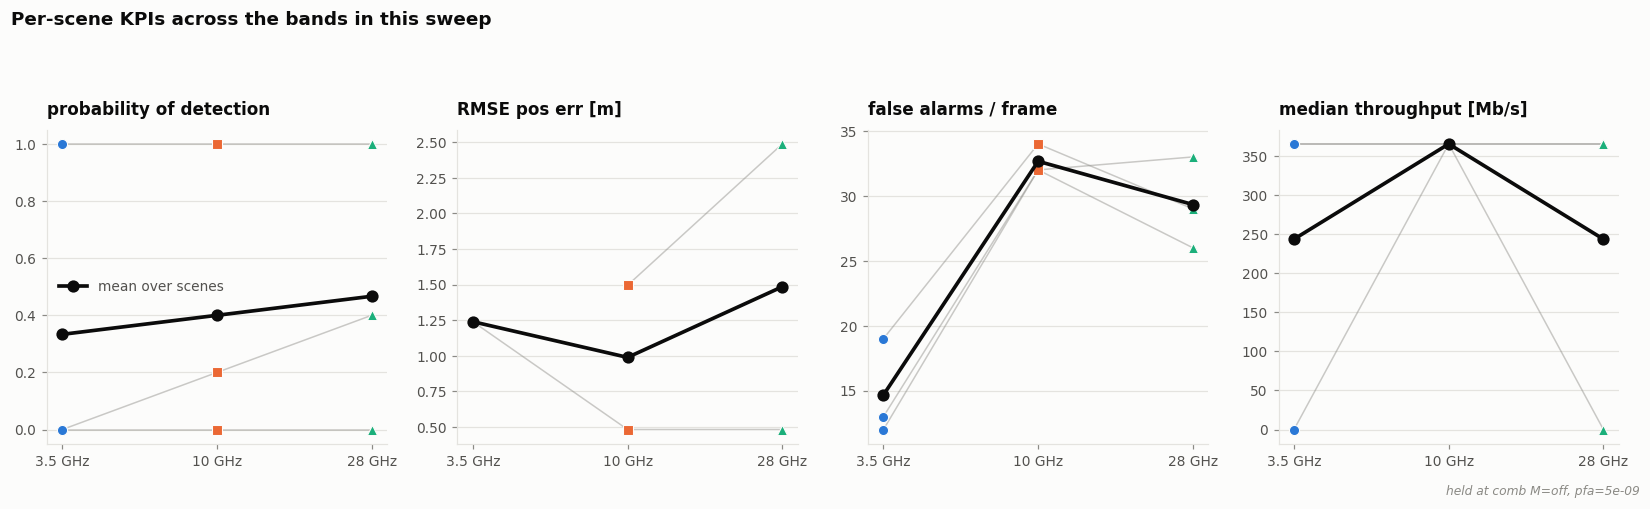

In [35]:
# Cross-band comparison: needs at least two bands in the csv.
if len(BANDS) < 2:
    print(f'skipped: only {len(BANDS)} band in this sweep '
          f'({[NAME[b] for b in BANDS]}) -- this plot compares bands')
else:
    # 3d  Scene-level slope chart: every scene, traced across the bands present
    fig, axes = plt.subplots(1, 4, figsize=(15, 4.4))
    metrics = [('prob_detection', 'probability of detection'), ('rmse_position_error_m', 'RMSE pos err [m]'),
               ('false_alarms_per_frame', 'false alarms / frame'), ('throughput_mbps', 'median throughput [Mb/s]')]
    for ax, (metric, lab) in zip(axes, metrics):
        src = scene if metric in SC_COLS else df
        tab = src.pivot_table(index='scene_id', columns='band', values=metric,
                              aggfunc='first' if metric in SC_COLS else 'median')
        tab = tab.reindex(columns=BANDS)   # an all-NaN band drops its column
        for sid, row in tab.iterrows():
            ax.plot(range(len(BANDS)), [row.get(b, np.nan) for b in BANDS], color=INK_MUTED,
                    lw=1, alpha=0.45, marker='')
        for i, b in enumerate(BANDS):
            ax.scatter([i] * len(tab), tab[b], s=44, color=COLOR[b], marker=MARK[b],
                       edgecolor=SURFACE, linewidth=0.7, zorder=3)
        ax.plot(range(len(BANDS)), [tab[b].mean() for b in BANDS], color=INK, lw=2.4, zorder=4,
                marker='o', ms=7, label='mean over scenes')
        ax.set_xticks(range(len(BANDS)), [NAME[b] for b in BANDS])
        ax.set_title(lab); ax.grid(axis='x', visible=False)
    axes[0].legend(loc='center left')
    fig.suptitle('Per-scene KPIs across the bands in this sweep', x=0.008,
                 ha='left', fontsize=12, weight='semibold', color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    save(fig, '03d_scene_slope_chart')


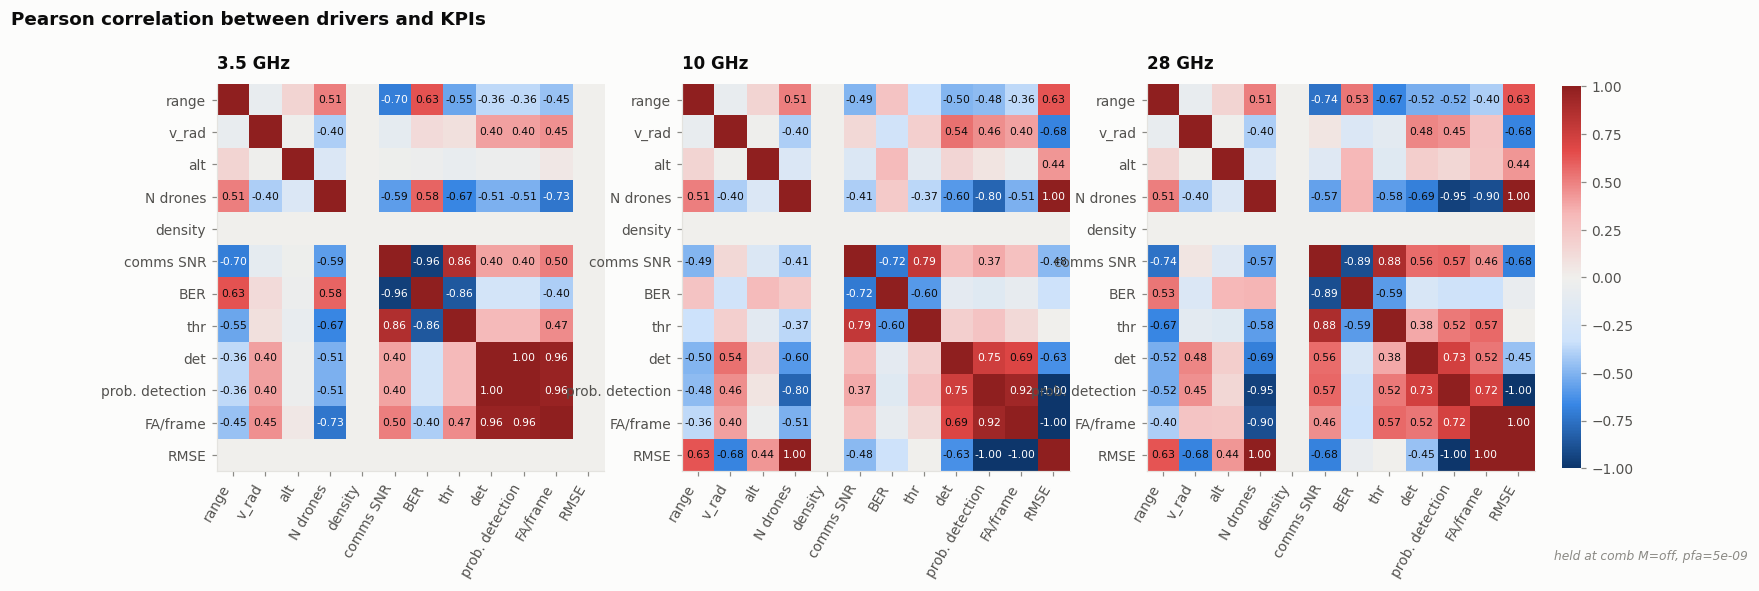

In [36]:
# 3e  Correlation structure of the metrics, per band
cols = ['true_range_m', 'true_radial_velocity_mps', 'z', 'num_drones', 'density',
        'snr', 'ber', 'throughput_mbps', 'detected', 'prob_detection',
        'false_alarms_per_frame', 'rmse_position_error_m']
short = ['range', 'v_rad', 'alt', 'N drones', 'density', 'comms SNR', 'BER', 'thr',
         'det', 'prob. detection', 'FA/frame', 'RMSE']
fig, axes = plt.subplots(1, 3, figsize=(16, 5.0))
for ax, b in zip(axes, BANDS):
    g = df[df.band == b][cols].astype(float)
    M = g.corr().to_numpy()
    im = ax.imshow(M, cmap=DIV, vmin=-1, vmax=1)
    ax.set_xticks(range(len(short)), short, rotation=60, ha='right')
    ax.set_yticks(range(len(short)), short)
    ax.set_title(NAME[b]); ax.grid(False)
    for i in range(len(short)):
        for j in range(len(short)):
            if np.isfinite(M[i, j]) and abs(M[i, j]) > 0.35 and i != j:
                ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=7,
                        color='#ffffff' if abs(M[i, j]) > 0.7 else INK)
cb = fig.colorbar(im, ax=axes, fraction=0.014, pad=0.02); cb.outline.set_visible(False)
fig.suptitle('Pearson correlation between drivers and KPIs', x=0.008, ha='left',
             fontsize=12, weight='semibold', color=INK)
save(fig, '03e_correlation_heatmaps')

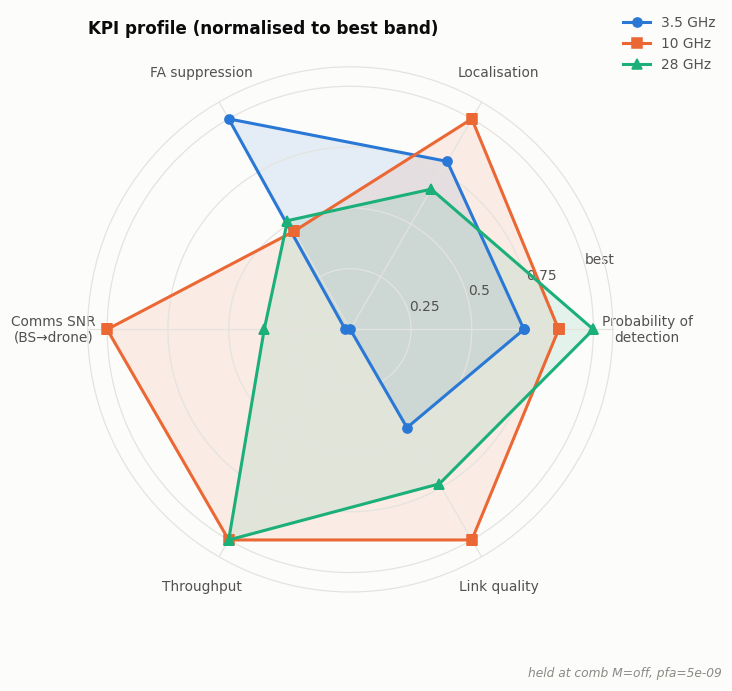

,Probability of\ndetection,Localisation,FA suppression,Comms SNR\n(BS→drone),Throughput,Link quality
band,,,,,,
3.5 GHz,0.333,0.807,0.064,2.332,0.000,0.35
10 GHz,0.400,1.011,0.030,112.849,365.121,0.75
28 GHz,0.467,0.673,0.033,39.943,365.121,0.55


In [37]:
# 3f  Normalised KPI profile — each metric scaled to its best band
prof = pd.DataFrame({
    'Probability of\ndetection': scene.groupby('band')['prob_detection'].mean(),
    'Localisation':  1 / scene.groupby('band')['rmse_position_error_m'].mean(),
    'FA suppression':1 / (1 + scene.groupby('band')['false_alarms_per_frame'].mean()),
    'Comms SNR\n(BS→drone)': 10 ** (df.groupby('band')['snr'].median() / 10),
    'Throughput':    df.groupby('band')['throughput_mbps'].median(),
    'Link quality':  df.groupby('band')['link_ok'].mean(),
})
prof_n = prof / prof.max()
labels = list(prof_n.columns)
ang = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
ang = np.concatenate([ang, ang[:1]])
fig, ax = plt.subplots(figsize=(7.0, 6.2), subplot_kw=dict(projection='polar'))
for b in BANDS:
    v = prof_n.loc[b].values
    v = np.concatenate([v, v[:1]])
    ax.plot(ang, v, color=COLOR[b], marker=MARK[b], ms=6, label=NAME[b])
    ax.fill(ang, v, color=COLOR[b], alpha=0.11)
ax.set_xticks(ang[:-1], labels, color=INK_2)
ax.tick_params(axis='x', pad=12)
ax.set_rlabel_position(15)
ax.set_yticks([0.25, 0.5, 0.75, 1.0], ['0.25', '0.5', '0.75', 'best'])
ax.set_ylim(0, 1.08); ax.grid(color=GRID)
ax.set_title('KPI profile (normalised to best band)', pad=22)
ax.legend(loc='upper right', bbox_to_anchor=(1.22, 1.12))
save(fig, '03f_kpi_radar')
display(prof.round(3).rename(index=NAME))

## 4. Scene geometry — where the drones are and what happens to them

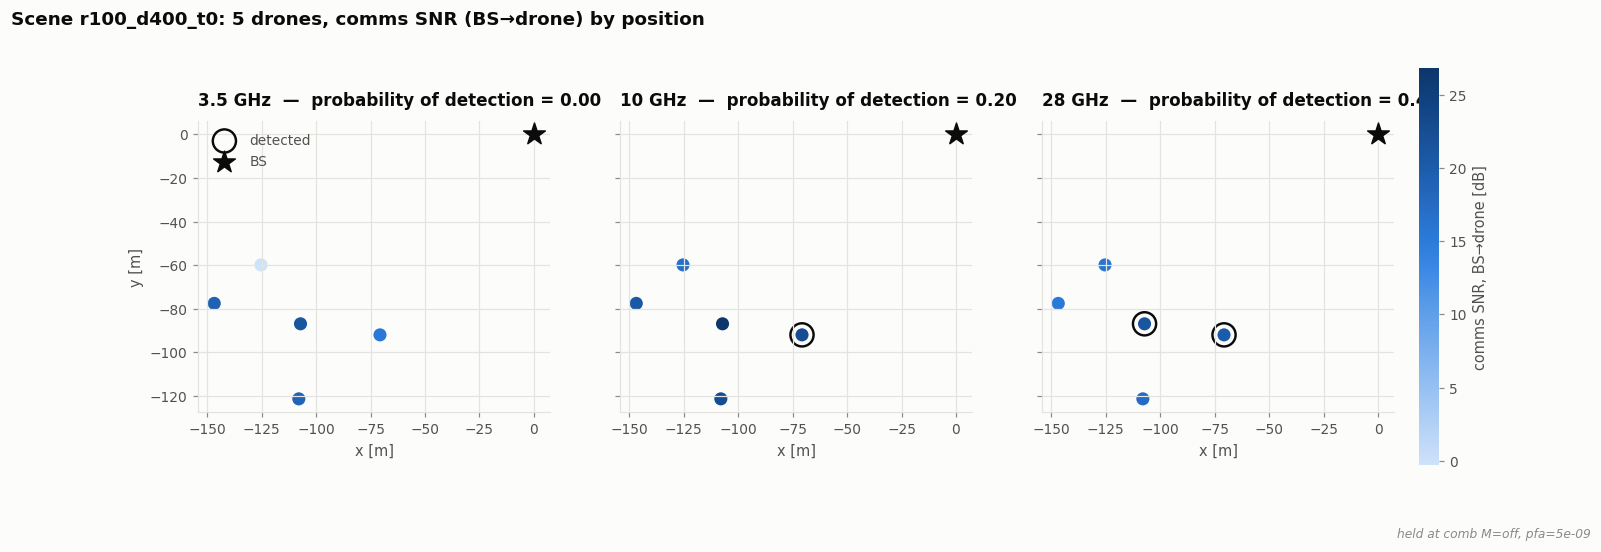

In [38]:
# 4a  Top-down scene map for the densest scene, coloured by SNR
# pick the scene with the most detections across bands — a map of an empty scene is dull
SCENE = df.groupby('scene_id')['detected'].sum().idxmax()
fig, axes = plt.subplots(1, len(BANDS), figsize=(4.85 * len(BANDS), 4.8),
                         sharex=True, sharey=True, squeeze=False)
axes = axes[0]
sub = df[df.scene_id == SCENE]
vmin, vmax = np.nanmin(sub.snr), np.nanmax(sub.snr)
for ax, b in zip(axes, BANDS):
    g = sub[sub.band == b]
    sc = ax.scatter(g.x, g.y, c=g.snr, cmap=SEQ, vmin=vmin, vmax=vmax, s=90,
                    edgecolor=SURFACE, linewidth=0.9)
    hit = g[g.detected]
    ax.scatter(hit.x, hit.y, s=230, facecolor='none', edgecolor=INK, linewidth=1.6,
               label='detected')
    ax.scatter([0], [0], marker='*', s=220, color=INK, zorder=5, label='BS')
    ax.set_title(f'{NAME[b]}  —  probability of detection = {g.prob_detection.iloc[0]:.2f}')
    ax.set_xlabel('x [m]'); ax.set_aspect('equal', 'box')
axes[0].set_ylabel('y [m]'); axes[0].legend(loc='upper left')
cb = fig.colorbar(sc, ax=axes, fraction=0.016, pad=0.02, label='comms SNR, BS→drone [dB]')
cb.outline.set_visible(False)
fig.suptitle(f'Scene {SCENE}: {sub.drone_id.nunique()} drones, comms SNR (BS→drone) by position', x=0.008, ha='left',
             fontsize=12, weight='semibold', color=INK)
save(fig, '04a_scene_map_snr')

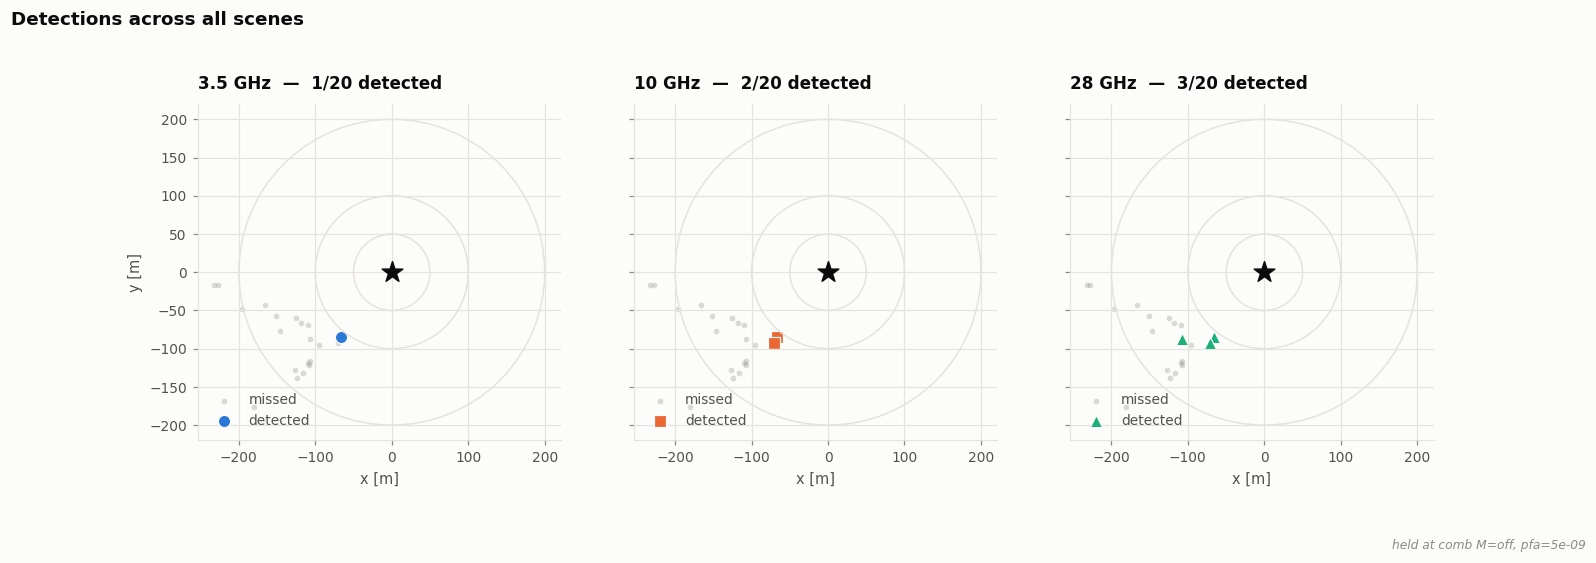

In [39]:
# 4b  All drones, all scenes: spatial layout coloured by band + detection
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.9), sharex=True, sharey=True)
for ax, b in zip(axes, BANDS):
    g = df[df.band == b]
    miss, hit = g[~g.detected], g[g.detected]
    ax.scatter(miss.x, miss.y, s=14, color=INK_MUTED, alpha=0.3, linewidths=0, label='missed')
    ax.scatter(hit.x, hit.y, s=64, color=COLOR[b], marker=MARK[b], edgecolor=SURFACE,
               linewidth=0.8, label='detected')
    ax.scatter([0], [0], marker='*', s=200, color=INK, zorder=5)
    for r in sorted(df.range_m.unique()):
        ax.add_patch(plt.Circle((0, 0), r, fill=False, color=GRID, lw=1))
    ax.set_title(f'{NAME[b]}  —  {hit.shape[0]}/{g.shape[0]} detected')
    ax.set_xlabel('x [m]'); ax.set_aspect('equal', 'box')
    ax.legend(loc='lower left')
axes[0].set_ylabel('y [m]')
fig.suptitle('Detections across all scenes',
             x=0.008, ha='left', fontsize=12, weight='semibold', color=INK)
save(fig, '04b_all_scenes_detection_map')

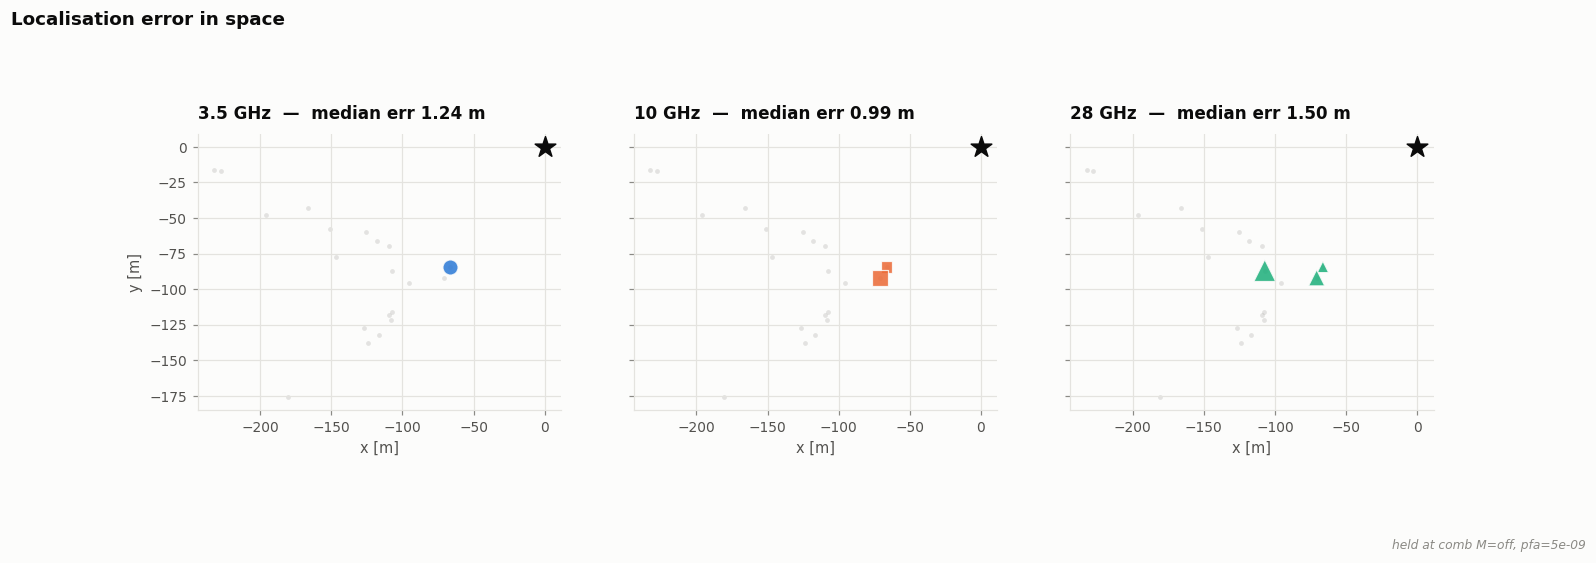

In [40]:
# 4c  Position-error field: detected drones, marker area ∝ error
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.9), sharex=True, sharey=True)
for ax, b in zip(axes, BANDS):
    g = det[det.band == b]
    ax.scatter(df.loc[df.band == b, 'x'], df.loc[df.band == b, 'y'], s=10,
               color=INK_MUTED, alpha=0.22, linewidths=0)
    ax.scatter(g.x, g.y, s=30 + 55 * g.position_error_m, color=COLOR[b], marker=MARK[b],
               alpha=0.85, edgecolor=SURFACE, linewidth=0.8)
    ax.scatter([0], [0], marker='*', s=200, color=INK, zorder=5)
    ax.set_title(f'{NAME[b]}  —  median err {g.position_error_m.median():.2f} m')
    ax.set_xlabel('x [m]'); ax.set_aspect('equal', 'box')
axes[0].set_ylabel('y [m]')
fig.suptitle('Localisation error in space',
             x=0.008, ha='left', fontsize=12, weight='semibold', color=INK)
save(fig, '04c_position_error_field')

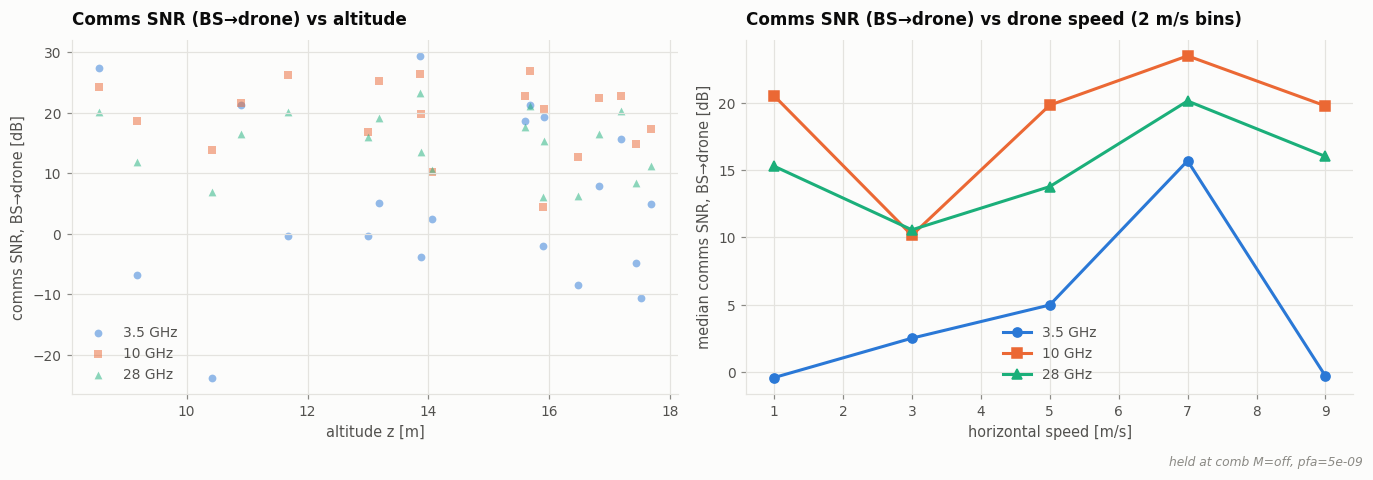

In [41]:
# 4d  Altitude and speed vs link quality
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for b in BANDS:
    g = df[df.band == b]
    axes[0].scatter(g.z, g.snr, s=26, color=COLOR[b], marker=MARK[b], alpha=0.5,
                    linewidths=0, label=NAME[b])
    c, m, n = binstat(g.speed_mps, g.snr, np.arange(0, 16, 2), 'median')
    axes[1].plot(c, m, color=COLOR[b], marker=MARK[b], label=NAME[b])
axes[0].set_xlabel('altitude z [m]'); axes[0].set_ylabel('comms SNR, BS→drone [dB]')
axes[0].set_title('Comms SNR (BS→drone) vs altitude'); axes[0].legend()
axes[1].set_xlabel('horizontal speed [m/s]'); axes[1].set_ylabel('median comms SNR, BS→drone [dB]')
axes[1].set_title('Comms SNR (BS→drone) vs drone speed (2 m/s bins)'); axes[1].legend()
fig.tight_layout()
save(fig, '04d_altitude_speed_vs_snr')

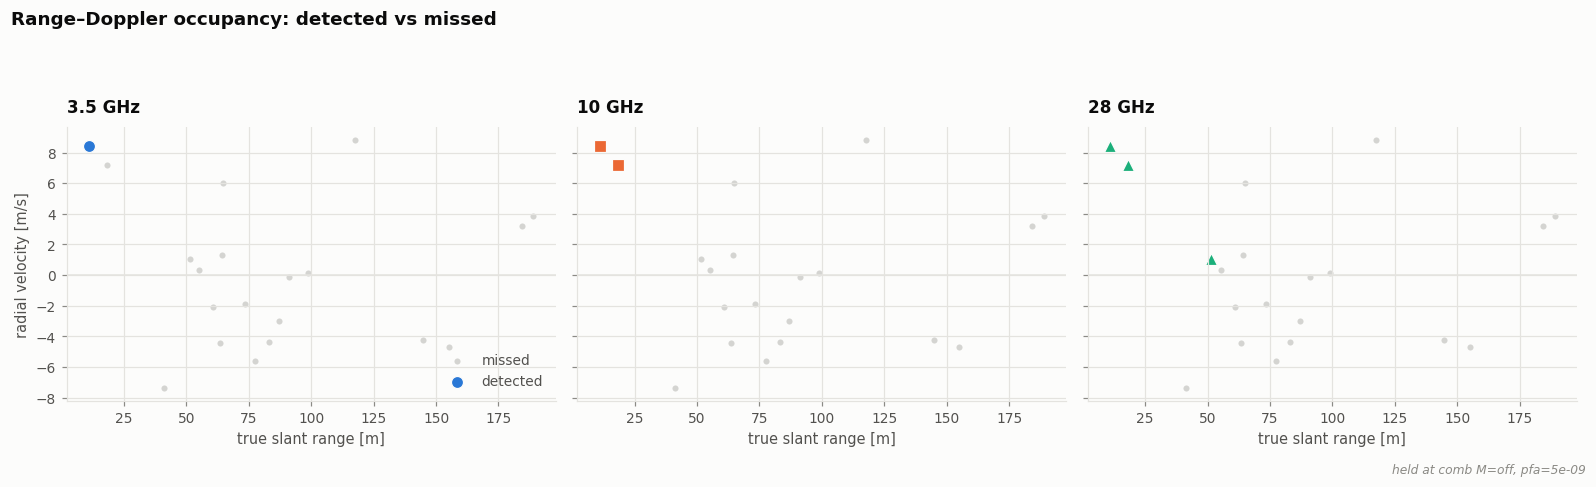

In [42]:
# 4e  Doppler / velocity picture: radial velocity vs range coloured by detection
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), sharey=True, sharex=True)
for ax, b in zip(axes, BANDS):
    g = df[df.band == b]
    miss, hit = g[~g.detected], g[g.detected]
    ax.scatter(miss.true_range_m, miss.true_radial_velocity_mps, s=16, color=INK_MUTED,
               alpha=0.35, linewidths=0, label='missed')
    ax.scatter(hit.true_range_m, hit.true_radial_velocity_mps, s=62, color=COLOR[b],
               marker=MARK[b], edgecolor=SURFACE, linewidth=0.8, label='detected')
    ax.axhline(0, color=GRID, lw=1)
    ax.set_xlabel('true slant range [m]'); ax.set_title(NAME[b])
axes[0].set_ylabel('radial velocity [m/s]'); axes[0].legend(loc='lower right')
fig.suptitle('Range–Doppler occupancy: detected vs missed', x=0.008,
             ha='left', fontsize=12, weight='semibold', color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.9])
save(fig, '04e_range_doppler_detection')

## 5. The JCAS trade-off — sensing against communication in one view

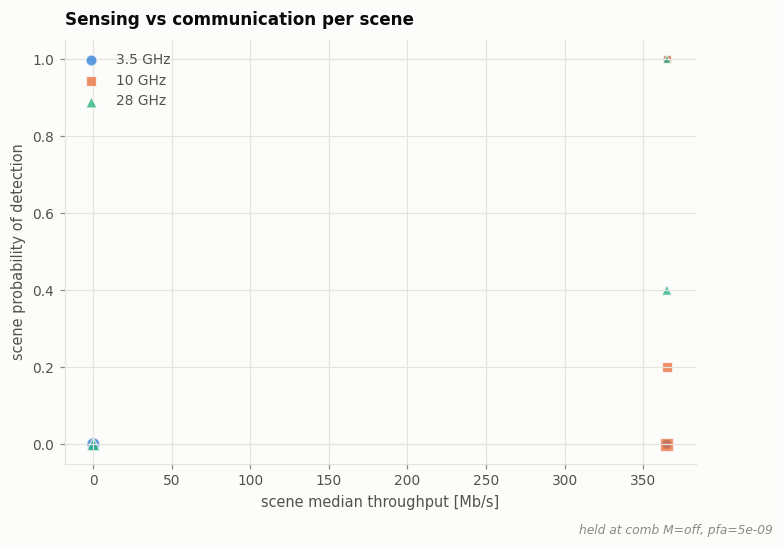

In [43]:
# 5a  Per-scene sensing vs comms
fig, ax = plt.subplots(figsize=(7.4, 5.0))
comm = df.groupby(['band', 'scene_id'])['throughput_mbps'].median().rename('thr')
sens = scene.set_index(['band', 'scene_id'])[['prob_detection', 'num_drones']]
J = sens.join(comm)
for b in BANDS:
    g = J.loc[b]
    ax.scatter(g.thr, g.prob_detection, s=26 + 3.4 * g.num_drones, color=COLOR[b],
               marker=MARK[b], alpha=0.75, edgecolor=SURFACE, linewidth=0.8, label=NAME[b])
ax.set_xlabel('scene median throughput [Mb/s]'); ax.set_ylabel('scene probability of detection')
ax.set_title('Sensing vs communication per scene')
ax.legend()
save(fig, '05a_jcas_tradeoff_scatter')

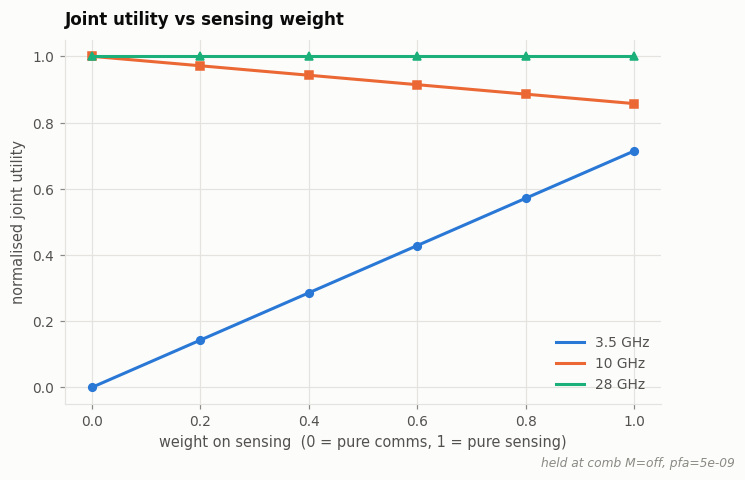

In [44]:
# 5b  Joint utility sweep: weight w on sensing, 1-w on normalised throughput
fig, ax = plt.subplots(figsize=(7.0, 4.3))
thr_n = df.groupby('band')['throughput_mbps'].median()
thr_n = thr_n / thr_n.max()
pd_n = scene.groupby('band')['prob_detection'].mean()
pd_n = pd_n / pd_n.max()
w = np.linspace(0, 1, 101)
for b in BANDS:
    ax.plot(w, w * pd_n[b] + (1 - w) * thr_n[b], color=COLOR[b], label=NAME[b])
    ax.plot(w[::20], (w * pd_n[b] + (1 - w) * thr_n[b])[::20], MARK[b], color=COLOR[b],
            ms=5, ls='none')
ax.set_xlabel('weight on sensing  (0 = pure comms, 1 = pure sensing)')
ax.set_ylabel('normalised joint utility')
ax.set_title('Joint utility vs sensing weight')
ax.legend()
save(fig, '05b_joint_utility_sweep')

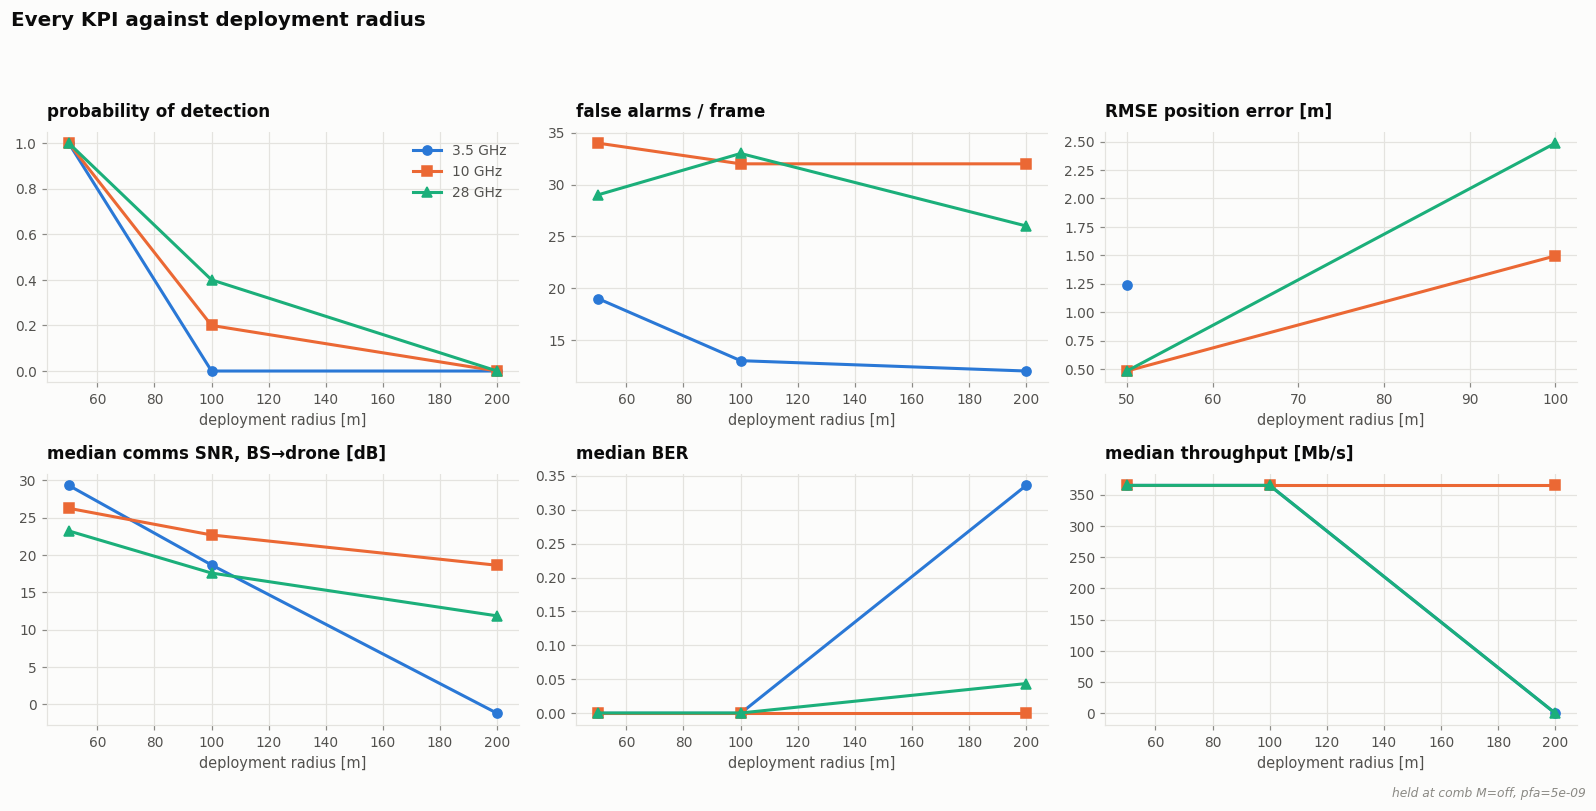

In [45]:
# 5c  Small-multiple grid: every KPI vs radius, one panel per KPI, band as series
fig, axes = plt.subplots(2, 3, figsize=(14.5, 7.2))
panels = [('prob_detection', scene, 'mean', 'probability of detection'),
          ('false_alarms_per_frame', scene, 'mean', 'false alarms / frame'),
          ('rmse_position_error_m', scene, 'mean', 'RMSE position error [m]'),
          ('snr', df, 'median', 'median comms SNR, BS→drone [dB]'),
          ('ber', df, 'median', 'median BER'),
          ('throughput_mbps', df, 'median', 'median throughput [Mb/s]')]
for ax, (metric, src, how, lab) in zip(axes.ravel(), panels):
    for b in BANDS:
        s = src[src.band == b].groupby('range_m')[metric].agg(how)
        ax.plot(s.index, s.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
    ax.set_xlabel('deployment radius [m]'); ax.set_title(lab)
axes[0, 0].legend()
fig.suptitle('Every KPI against deployment radius', x=0.008, ha='left', fontsize=13,
             weight='semibold', color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.93])
save(fig, '05c_all_kpis_vs_radius')

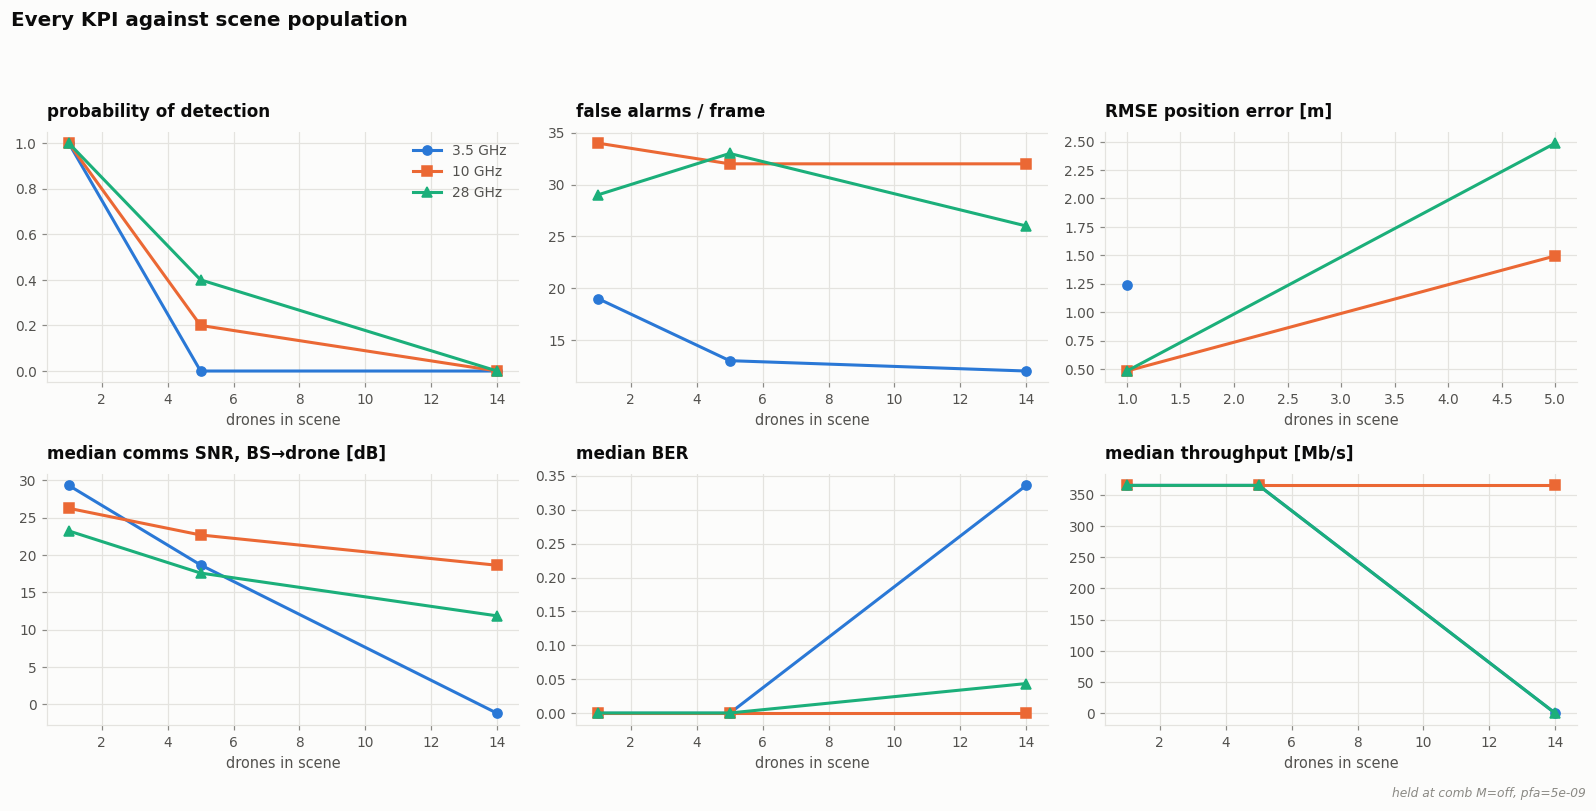

In [46]:
# 5d  Same grid, against scene population
fig, axes = plt.subplots(2, 3, figsize=(14.5, 7.2))
for ax, (metric, src, how, lab) in zip(axes.ravel(), panels):
    for b in BANDS:
        s = src[src.band == b].groupby('num_drones')[metric].agg(how)
        ax.plot(s.index, s.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
    ax.set_xlabel('drones in scene'); ax.set_title(lab)
axes[0, 0].legend()
fig.suptitle('Every KPI against scene population', x=0.008, ha='left', fontsize=13,
             weight='semibold', color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.93])
save(fig, '05d_all_kpis_vs_population')

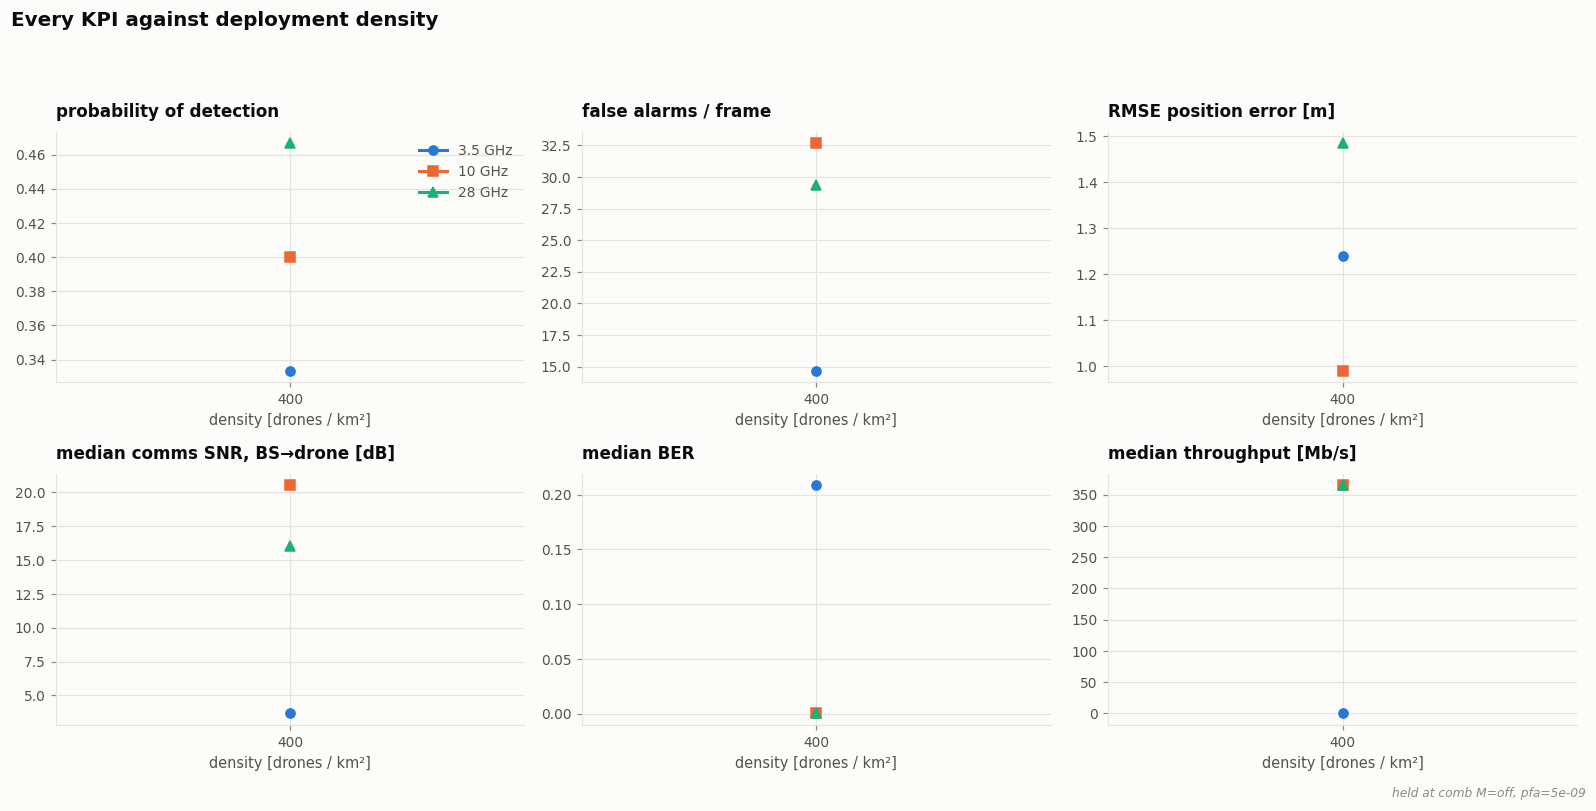

In [47]:
# 5e  Same grid, against density
fig, axes = plt.subplots(2, 3, figsize=(14.5, 7.2))
for ax, (metric, src, how, lab) in zip(axes.ravel(), panels):
    for b in BANDS:
        s = src[src.band == b].groupby('density_km2')[metric].agg(how)
        ax.plot(s.index, s.values, color=COLOR[b], marker=MARK[b], label=NAME[b])
    ax.set_xticks(sorted(df.density_km2.unique()))
    ax.set_xlabel('density [drones / km²]'); ax.set_title(lab)
axes[0, 0].legend()
fig.suptitle('Every KPI against deployment density', x=0.008, ha='left', fontsize=13,
             weight='semibold', color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.93])
save(fig, '05e_all_kpis_vs_density')

## 6. The waveform and detector axes — comb spacing and $P_{fa}$

Sections 0-5 above hold `comb_spacing` and `pfa` fixed at one slice (stamped on every
figure) so that band-vs-band comparisons are like-for-like. This section is the other
cut: band is mostly held in the background and the two new sweep axes are the subject.

They are not the same kind of axis:

* **`pfa`** is a *detector* knob and it is **free**. Every value is scored off the SAME
  finished radar cube from the SAME drop (`monte_carlo.py` accepts a LIST of
  `detect_kwargs`), so a pfa sweep costs one extra CFAR pass, not another ray-traced
  trial — and because the physics is held exactly fixed across it, $P_d$ vs false-alarm
  really is a ROC rather than a comparison of different random draws.
* **`comb_spacing` M** is a *waveform* knob and it is **expensive**: each M is its own
  trial. It is also the JCAS split itself — the comb takes 1/M of the subcarriers from
  the comms link and hands them to the radar, and divides the unambiguous range by M
  while leaving range resolution untouched.

Everything here reads `df_all` / `scene_all` (the unsliced frame) and is drawn without
the held-slice stamp. Cells self-skip with a printed reason when the sweep in the CSV
carries only one value of the axis they need.

In [48]:
# Section 6 works off every row rather than the held slice, so its figures pass note=''.
PFA_SHADE = {}          # pfa -> colour, dark = strict threshold, light = permissive
if len(PFAS) > 1:
    _idx = np.linspace(len(BLUES) - 1, 3, len(PFAS)).round().astype(int)
    PFA_SHADE = {p: BLUES[i] for p, i in zip(PFAS, _idx)}
elif PFAS:
    PFA_SHADE = {PFAS[0]: COLOR[BANDS[0]]}
COMB_LABEL = {m: ('comb off' if m == 0 else f'M = {m:g}') for m in COMBS}
COMB_MARK = ['o', 's', '^', 'D', 'v', 'P']

def axis_note(ax, msg):
    '''Say on the figure itself why a panel is empty/flat, instead of drawing a blank.'''
    ax.text(0.5, 0.5, msg, transform=ax.transAxes, ha='center', va='center',
            color=INK_MUTED, fontsize=9)

def pfa_ticks(ax):
    ax.set_xscale('log')
    ax.set_xticks(PFAS, [f'{p:.0e}' for p in PFAS])
    ax.set_xlabel('CFAR design $P_{fa}$')

# The pfa axis is paired for free, since every threshold is scored off the same drop.
# The comb axis is not -- each M is its own trial -- so a partial sweep would have the
# comb figures reading scene mix rather than waveform.
def paired_over_comb(frame):
    '''Rows whose scene_id was simulated at every comb spacing (within each band).'''
    if len(COMBS) < 2:
        return frame
    keep = []
    for b in BANDS:
        gb = frame[frame.band == b]
        sids = set.intersection(*(set(gb.loc[gb.comb_spacing == m, 'scene_id'])
                                  for m in COMBS)) if len(gb) else set()
        keep.append(gb[gb.scene_id.isin(sids)])
    return pd.concat(keep, ignore_index=True) if keep else frame

df_comb, scene_comb = paired_over_comb(df_all), paired_over_comb(scene_all)
_cells = lambda f: set(zip(f.band, f.scene_id))   # scene_ids repeat across bands
_n_all, _n_pair = len(_cells(scene_all)), len(_cells(scene_comb))
if _n_pair < _n_all:
    print(f'comb figures use {_n_pair} of {_n_all} scenes -- the rest are not yet '
          f'simulated at every M (unbalanced sweep)')

print(f'section 6 axes -- pfa: {PFAS}  comb: {COMBS}  bands: {[NAME[b] for b in BANDS]}')
print('scene rows per (band, comb, pfa) cell:')
display(scene_all.groupby(['band', 'comb_spacing', 'pfa']).size().rename('scenes'))

section 6 axes -- pfa: [np.float64(5e-09), np.float64(5e-08), np.float64(5e-07)]  comb: [np.int64(0), np.int64(2), np.int64(4)]  bands: ['3.5 GHz', '10 GHz', '28 GHz']
scene rows per (band, comb, pfa) cell:


band  comb_spacing  pfa         
3.5   0             5.000000e-09    3
                    5.000000e-08    3
                    5.000000e-07    3
      2             5.000000e-09    3
                    5.000000e-08    3
                    5.000000e-07    3
      4             5.000000e-09    3
                    5.000000e-08    3
                    5.000000e-07    3
10.0  0             5.000000e-09    3
                    5.000000e-08    3
                    5.000000e-07    3
      2             5.000000e-09    3
                    5.000000e-08    3
                    5.000000e-07    3
      4             5.000000e-09    3
                    5.000000e-08    3
                    5.000000e-07    3
28.0  0             5.000000e-09    3
                    5.000000e-08    3
                    5.000000e-07    3
      2             5.000000e-09    3
                    5.000000e-08    3
                    5.000000e-07    3
      4             5.000000e-09    3
                 

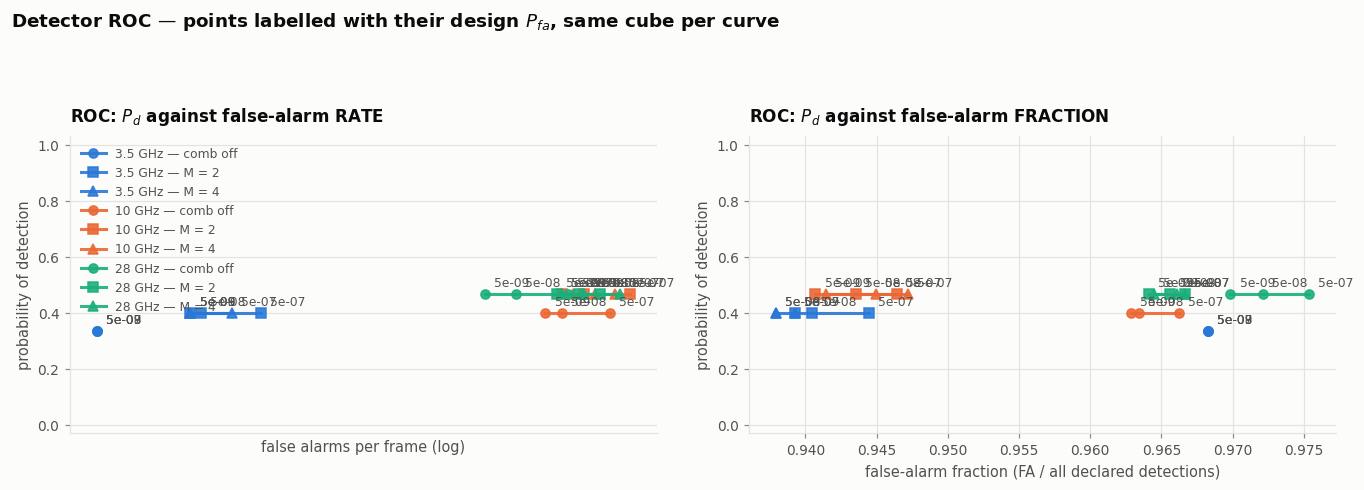

In [49]:
# 6a  Detector ROC. Every pfa was scored off the same cube, so the points differ only
# by threshold.
if len(PFAS) < 2:
    print(f'skipped: sweep carries a single pfa ({PFAS}) -- nothing to trace')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
    for b in BANDS:
        for m in COMBS:
            g = (scene_all[(scene_all.band == b) & (scene_all.comb_spacing == m)]
                 .groupby('pfa')[['prob_detection', 'false_alarms_per_frame',
                                  'false_alarm_fraction']].mean().reindex(PFAS))
            if g['prob_detection'].isna().all():
                continue
            mk = COMB_MARK[COMBS.index(m) % len(COMB_MARK)]
            lab = f'{NAME[b]} — {COMB_LABEL[m]}'
            for ax, xcol, in zip(axes, ['false_alarms_per_frame', 'false_alarm_fraction']):
                ax.plot(g[xcol], g['prob_detection'], color=COLOR[b], marker=mk,
                        ms=6, alpha=0.9, label=lab)
                for p, x, y in zip(g.index, g[xcol], g['prob_detection']):
                    if np.isfinite(x) and np.isfinite(y):
                        ax.annotate(f'{p:.0e}', (x, y), textcoords='offset points',
                                    xytext=(6, 5), fontsize=8, color=INK_2)
    axes[0].set_xscale('symlog', linthresh=1)
    axes[0].set_xlabel('false alarms per frame (log)')
    axes[1].set_xlabel('false-alarm fraction (FA / all declared detections)')
    for ax in axes:
        ax.set_ylabel('probability of detection')
        ax.set_ylim(-0.03, 1.03)
    axes[0].set_title('ROC: $P_d$ against false-alarm RATE')
    axes[1].set_title('ROC: $P_d$ against false-alarm FRACTION')
    axes[0].legend(loc='upper left', fontsize=8)
    fig.suptitle('Detector ROC — points labelled with their design $P_{fa}$, same cube per curve',
                 x=0.008, ha='left', fontsize=12, weight='semibold', color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    save(fig, '06a_detector_roc', note='')

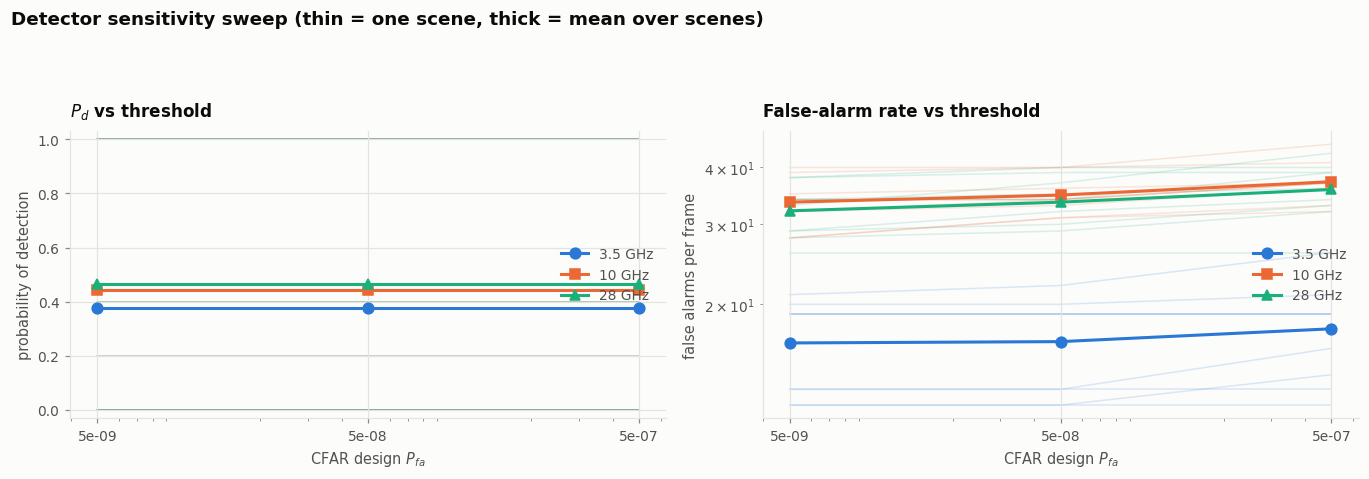

In [50]:
# 6b  The two detector KPIs against pfa directly. Faint lines are individual scenes,
# each traced across its own thresholds off the same cube; the heavy line is the mean.
# FA rate is log-y because it moves by orders of magnitude while Pd moves by tenths.
if len(PFAS) < 2:
    print('skipped: single pfa in this sweep')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    for b in BANDS:
        g = scene_all[scene_all.band == b]
        for ax, col in zip(axes, ['prob_detection', 'false_alarms_per_frame']):
            for sid, s in g.groupby(['scene_id', 'comb_spacing']):
                s = s.sort_values('pfa')
                ax.plot(s.pfa, s[col], color=COLOR[b], alpha=0.16, lw=1, zorder=1)
            m = g.groupby('pfa')[col].mean().reindex(PFAS)
            ax.plot(m.index, m.values, color=COLOR[b], marker=MARK.get(b, 'o'), ms=7,
                    zorder=3, label=NAME[b])
    for ax in axes:
        pfa_ticks(ax)
        ax.legend()
    axes[0].set_ylabel('probability of detection'); axes[0].set_ylim(-0.03, 1.03)
    axes[0].set_title('$P_d$ vs threshold')
    axes[1].set_yscale('log'); axes[1].set_ylabel('false alarms per frame')
    axes[1].set_title('False-alarm rate vs threshold')
    fig.suptitle('Detector sensitivity sweep (thin = one scene, thick = mean over scenes)',
                 x=0.008, ha='left', fontsize=12, weight='semibold', color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    save(fig, '06b_pd_fa_vs_pfa', note='')

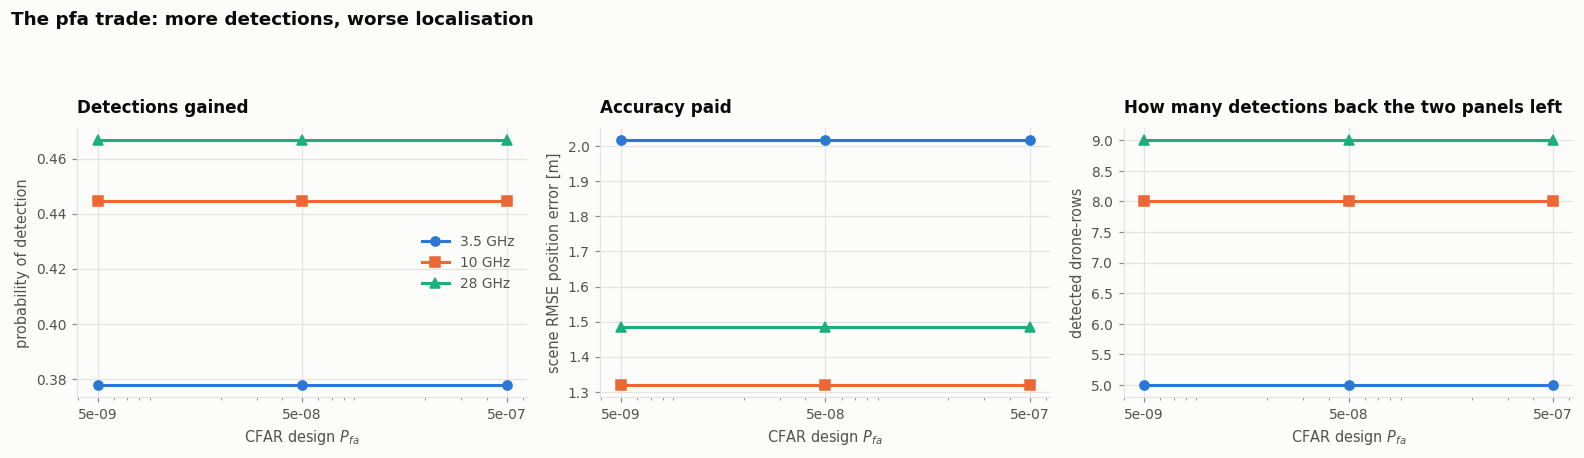

In [51]:
# 6c  What loosening the threshold costs: raising pfa admits weaker returns, so Pd
# rises while the marginal targets localise worse. Third panel is the detection count
# the other two average over.
if len(PFAS) < 2:
    print('skipped: single pfa in this sweep')
else:
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
    panels = [('prob_detection', scene_all, 'mean', 'probability of detection'),
              ('rmse_position_error_m', scene_all, 'mean', 'scene RMSE position error [m]'),
              ('detected', df_all, 'sum', 'detected drone-rows')]
    for ax, (col, src, how, lab) in zip(axes, panels):
        for b in BANDS:
            s = src[src.band == b].groupby('pfa')[col].agg(how).reindex(PFAS)
            ax.plot(s.index, s.values, color=COLOR[b], marker=MARK.get(b, 'o'),
                    ms=6, label=NAME[b])
        pfa_ticks(ax)
        ax.set_ylabel(lab)
        if not np.isfinite(src.groupby('pfa')[col].agg(how).to_numpy(float)).any():
            axis_note(ax, 'no detections at any threshold\n(nothing to score)')
    axes[0].set_title('Detections gained'); axes[1].set_title('Accuracy paid')
    axes[2].set_title('How many detections back the two panels left')
    axes[0].legend()
    fig.suptitle('The pfa trade: more detections, worse localisation',
                 x=0.008, ha='left', fontsize=12, weight='semibold', color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    save(fig, '06c_pfa_detection_vs_accuracy', note='')

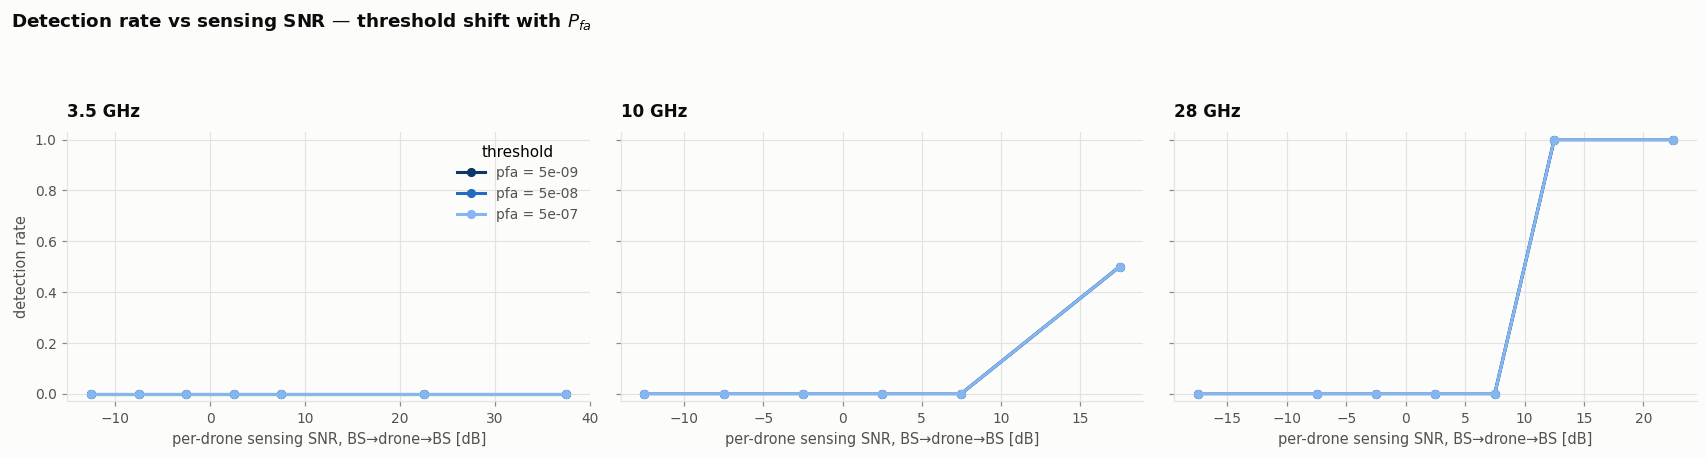

In [52]:
# 6d  Where the threshold sits, in dB. Detection rate binned against each drone's own
# two-way sensing SNR, one curve per pfa — a looser threshold should shift the curve
# left, as weaker returns start passing. Shade encodes pfa, dark = strict.
if len(PFAS) < 2:
    print('skipped: needs >1 pfa')
elif not np.isfinite(df_all['sensing_snr']).any():
    print('skipped: every sensing_snr_db is -inf (no monostatic return in this sweep)')
else:
    sbins = np.arange(-40, 45, 5)
    fig, axes = plt.subplots(1, len(BANDS), figsize=(5.2 * len(BANDS), 4.2),
                             sharey=True, squeeze=False)
    axes = axes[0]
    for ax, b in zip(axes, BANDS):
        g = df_all[df_all.band == b]
        for p in PFAS:
            gp = g[g.pfa == p]
            c, v, n = binstat(gp.sensing_snr, gp.detected.astype(float), sbins, 'mean')
            ok = n > 0
            ax.plot(c[ok], v[ok], color=PFA_SHADE[p], marker='o', ms=5,
                    label=f'pfa = {p:.0e}')
        ax.set_xlabel('per-drone sensing SNR, BS→drone→BS [dB]')
        ax.set_title(NAME[b])
    axes[0].set_ylabel('detection rate'); axes[0].set_ylim(-0.03, 1.03)
    axes[0].legend(title='threshold')
    fig.suptitle('Detection rate vs sensing SNR — threshold shift with $P_{fa}$',
                 x=0.008, ha='left', fontsize=12, weight='semibold', color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    save(fig, '06d_detection_vs_sensing_snr_by_pfa', note='')

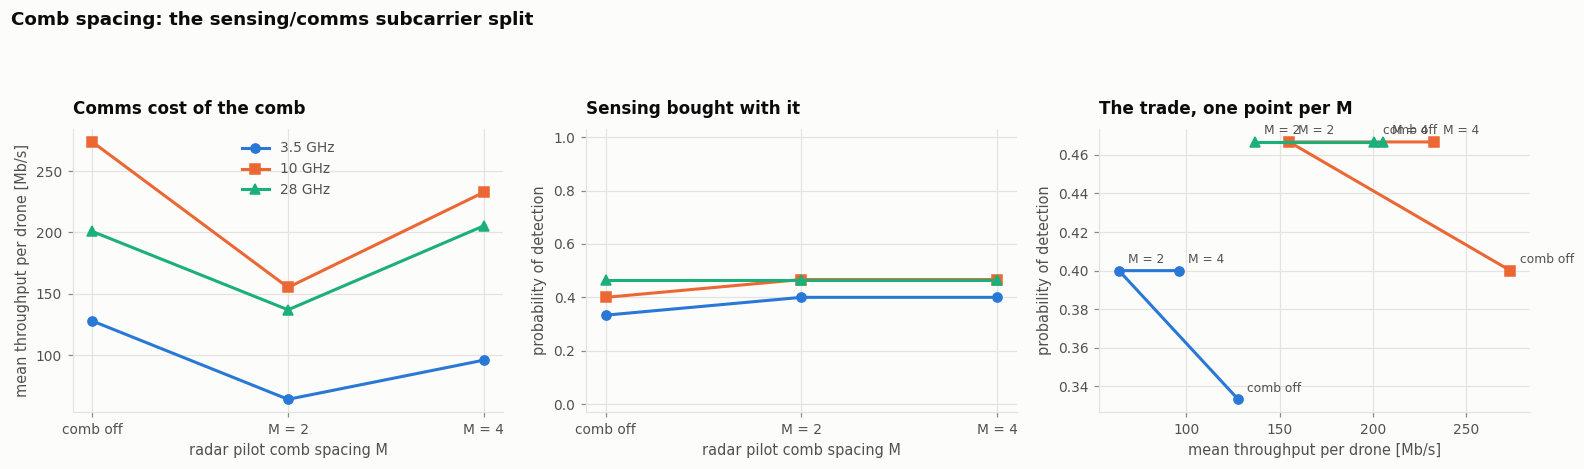

range_resolution_m  max_unambiguous_range_m
band comb_spacing                                             
3.5  0                           1.52                  4996.54
     2                           1.52                  2498.27
     4                           1.52                  1249.14
10.0 0                           1.52                  2498.27
     2                           1.52                  1249.14
     4                           1.52                   624.57
28.0 0                           1.52                  1249.14
     2                           1.52                   624.57
     4                           1.52                   312.28

In [53]:
# 6e  The comb axis — the sensing/comms split. M hands 1/M of the subcarriers to the
# radar comb; M = 0 is the comb off. Unambiguous range divides by M, a cost this panel
# does not show. Throughput is the mean, not the median used elsewhere, which collapses
# to a flat 0 Mb/s when most links sit below the usable-BER threshold.
if len(COMBS) < 2:
    print(f'skipped: sweep carries a single comb spacing ({COMBS})')
else:
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))
    xs = range(len(COMBS))
    for b in BANDS:
        thr = df_comb[df_comb.band == b].groupby('comb_spacing')['throughput_mbps'].mean()
        pdet = scene_comb[scene_comb.band == b].groupby('comb_spacing')['prob_detection'].mean()
        thr, pdet = thr.reindex(COMBS), pdet.reindex(COMBS)
        axes[0].plot(xs, thr.values, color=COLOR[b], marker=MARK.get(b, 'o'), label=NAME[b])
        axes[1].plot(xs, pdet.values, color=COLOR[b], marker=MARK.get(b, 'o'), label=NAME[b])
        axes[2].plot(thr.values, pdet.values, color=COLOR[b], marker=MARK.get(b, 'o'),
                     label=NAME[b])
        for m, x, y in zip(COMBS, thr.values, pdet.values):
            if np.isfinite(x) and np.isfinite(y):
                axes[2].annotate(COMB_LABEL[m], (x, y), textcoords='offset points',
                                 xytext=(6, 5), fontsize=8, color=INK_2)
    for ax in axes[:2]:
        ax.set_xticks(list(xs), [COMB_LABEL[m] for m in COMBS])
        ax.set_xlabel('radar pilot comb spacing M')
    axes[0].set_ylabel('mean throughput per drone [Mb/s]'); axes[0].set_title('Comms cost of the comb')
    axes[1].set_ylabel('probability of detection'); axes[1].set_title('Sensing bought with it')
    axes[1].set_ylim(-0.03, 1.03)
    axes[2].set_xlabel('mean throughput per drone [Mb/s]'); axes[2].set_ylabel('probability of detection')
    axes[2].set_title('The trade, one point per M')
    axes[0].legend()
    fig.suptitle('Comb spacing: the sensing/comms subcarrier split',
                 x=0.008, ha='left', fontsize=12, weight='semibold', color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    save(fig, '06e_comb_tradeoff', note='')

    # range geometry the comb sets, from the CSV's own per-trial columns
    geom = (df_all.groupby(['band', 'comb_spacing'])
            [['range_resolution_m', 'max_unambiguous_range_m']].first().round(2))
    display(geom)

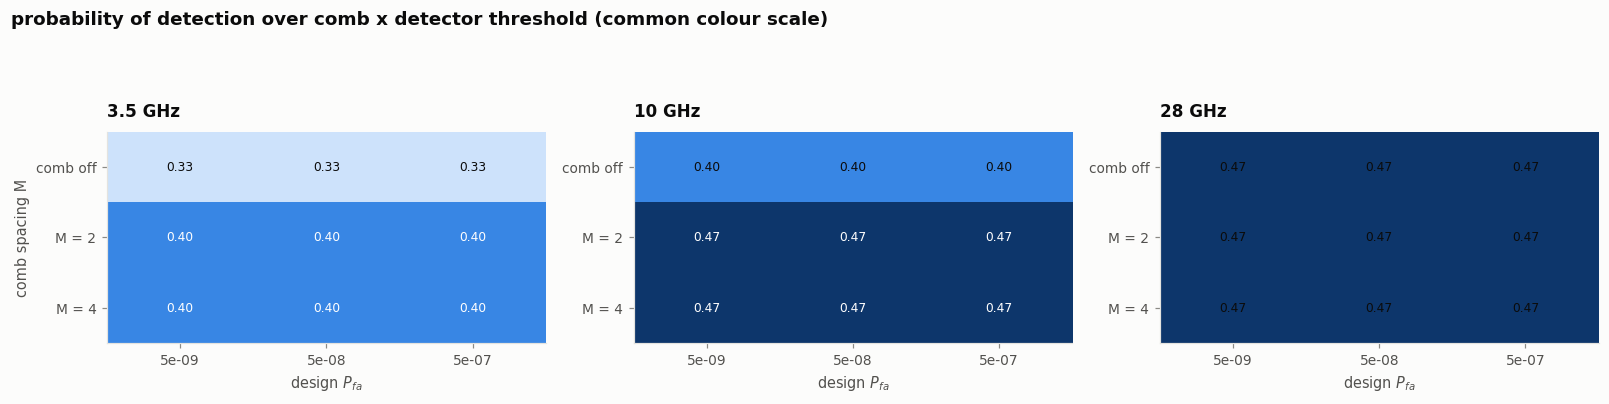

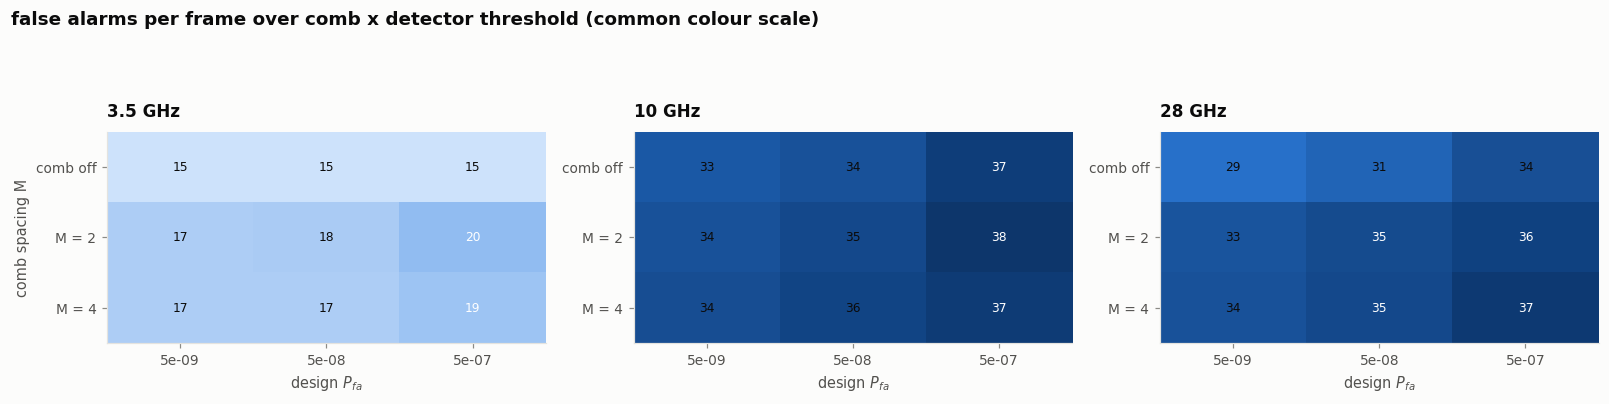

In [54]:
# 6f  Both new axes at once: comb x pfa, per band. The detector and waveform knobs are
# not independent — a sparser comb changes the cube the CFAR thresholds — so read this as
# a grid rather than two separate line plots.
if len(PFAS) < 2 or len(COMBS) < 2:
    print('skipped: needs >1 pfa AND >1 comb spacing')
else:
    for metric, src, how, fmt, lab, fname in [
            ('prob_detection', scene_comb, 'mean', '{:.2f}', 'probability of detection',
             '06f_heat_pd_comb_pfa'),
            ('false_alarms_per_frame', scene_comb, 'mean', '{:.0f}', 'false alarms per frame',
             '06g_heat_fa_comb_pfa')]:
        fig, axes = plt.subplots(1, len(BANDS), figsize=(4.9 * len(BANDS), 3.7),
                                 squeeze=False)
        axes = axes[0]
        pivs = [src[src.band == b].pivot_table(index='comb_spacing', columns='pfa',
                                               values=metric, aggfunc=how)
                .reindex(index=COMBS, columns=PFAS) for b in BANDS]
        stack = np.concatenate([p.to_numpy(float).ravel() for p in pivs])
        vmin, vmax = (np.nanmin(stack), np.nanmax(stack)) if np.isfinite(stack).any() else (0, 1)
        for ax, b, piv in zip(axes, BANDS, pivs):
            heat(ax, piv, fmt=fmt, vmin=vmin, vmax=vmax, title=NAME[b])
            ax.set_xticks(range(len(PFAS)), [f'{p:.0e}' for p in PFAS])
            ax.set_yticks(range(len(COMBS)), [COMB_LABEL[m] for m in COMBS])
            ax.set_xlabel('design $P_{fa}$')
        axes[0].set_ylabel('comb spacing M')
        fig.suptitle(f'{lab} over comb x detector threshold (common colour scale)',
                     x=0.008, ha='left', fontsize=12, weight='semibold', color=INK)
        fig.tight_layout(rect=[0, 0, 1, 0.88])
        save(fig, fname, note='')

In [55]:
print('figures written to', PLOTS.resolve())
for p in sorted(PLOTS.glob('*.png')):
    print(' ', p.name)

figures written to /home/kb/JMU/Y25_Sum_26/plots
  00_kpi_headline.png
  01a_snr_cdf.png
  01b_snr_vs_true_range.png
  01c_snr_by_radius_box.png
  01d_snr_by_density_violin.png
  01e_throughput_cdf.png
  01f_throughput_vs_snr.png
  01g_ber_vs_snr.png
  01h_throughput_vs_radius_density.png
  01i_throughput_vs_num_drones.png
  01j_coverage_vs_snr_threshold.png
  01k_link_state_and_usable_rate.png
  01l_heat_snr.png
  01m_heat_throughput.png
  01n_heat_ber.png
  01o_heat_ber_mean.png
  01q_ber_trends.png
  02a_pd_vs_radius_density.png
  02b_pd_vs_num_drones.png
  02c_heat_false_alarms.png
  02d_false_alarms_vs_radius_population.png
  02e_pd_vs_fa_operating_points.png
  02f_heat_pd.png
  02g_heat_rmse.png
  02h_rmse_vs_radius_density.png
  02i_position_error_cdf_strip.png
  02j_range_vs_azimuth_error.png
  02k_errors_vs_true_range.png
  02l_azimuth_dependence.png
  02m_polar_detection_map.png
  02n_detection_rate_vs_range_snr.png
  02o_detection_vs_kinematics.png
  03a_paired_deltas_cdf.pn